**PHASE 1 OF 3 : DATA PREPROCESSING AND DATA VISUALIZATION - DONE**

At first my approach is to download the data from official website ,
then I will preproces it i.e. and visualize it to find out nature
of the dataset and then I will use it for model building

In [ ]:
import os
import json
import glob

import pandas as pd
import numpy as np

from collections import Counter
import matplotlib.pyplot as plt

# first i will Display all dataframe columns
pd.set_option("display.max_columns", None)

print("All libraries are imported successfully")

All libraries are imported successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# STEP 2 :i will now Load all JSON Files

"""

dataset_path = "/content/drive/MyDrive/mental_health_mendely_dataset/*.json"

files=glob.glob(dataset_path)

print("total number of json files in dataset folder:",len(files))
#print(files)

total number of json files in dataset folder: 1000


In [ ]:
all_data = []
for i in files:
  with open(i, "r", encoding="utf-8") as f:
    data = json.load(f)
    all_data.extend(data)

print("total combined conversarions:", len(all_data))

total combined conversarions: 20202


In [ ]:
output_file_path = "/content/drive/MyDrive/mental_health_mendely_dataset/combined_dataset.json"

with open(output_file_path, "w", encoding = "utf-8") as f:
  json.dump(all_data, f, ensure_ascii= False, indent = 4)

print("combined json data successfully saved to:", output_file_path)


combined json data successfully saved to: /content/drive/MyDrive/mental_health_mendely_dataset/combined_dataset.json


In [ ]:

output_file_path = "/content/drive/MyDrive/mental_health_mendely_dataset/combined_dataset.json"

with open(output_file_path, "w", encoding="utf-8") as f:
    json.dump(all_data, f, ensure_ascii=False, indent=4)

print("Data successfully saved to:", output_file_path)

In [ ]:
#converting to dataframe and saving as excel or csv file
df=pd.DataFrame(all_data)
print("first five rows just to see:\n", df.head())

dataset_path = "/content/drive/MyDrive/mental_health_mendely_dataset/"


df.to_csv(dataset_path +"CSV_mental_health_dataset.csv", index= False)


df.to_excel(dataset_path + "Excel_mental_health_dataset.xlsx", index = False)

print("csv and xlsx files are successfully saved on drive at:", dataset_path)



first five rows just to see:
                                                ellie  \
0     Good morning, Noah. How are you feeling today?   
1  Sounds like the weekend went by fast. Did anyt...   
2  You mentioned feeling stuck in that cycle befo...   
3  And after the scroll, do you feel better or ju...   
4  What would “better” look like to you in that m...   

                                         participant persona persona_dp  \
0  Hey… I’m okay, you know? Just one of those “is...    noah        ndp   
1  Nah, nothing huge. I hit snooze three times, t...    noah        ndp   
2  It’s like a quiet narrator, not yelling, just…...    noah        ndp   
3  Distracted, I guess. The irritation’s gone, bu...    noah        ndp   
4  Honestly, just rolling out of bed without the ...    noah        ndp   

                                                 peu  
0  somatic_fatigue_sleep_issues, rumination_affec...  
1  somatic_fatigue_sleep_issues, rumination_affec...  
2  cognitive_dist

In [ ]:
#dataset info

print("shape of dataset:\n", df.shape,"\n")
print("columns of dataset:\n", df.columns,"\n")
print("dataset info:\n", df.info(),"\n")
print("dataset describe:\n", df.describe(),"\n")
print("unique values in peus column:\n", df.peu.unique)

shape of dataset:
 (20202, 5) 

columns of dataset:
 Index(['ellie', 'participant', 'persona', 'persona_dp', 'peu'], dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20202 entries, 0 to 20201
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ellie        20202 non-null  object
 1   participant  20202 non-null  object
 2   persona      20202 non-null  object
 3   persona_dp   20202 non-null  object
 4   peu          20202 non-null  object
dtypes: object(5)
memory usage: 789.3+ KB
dataset info:
 None 

dataset describe:
                                                   ellie participant persona  \
count                                             20202       20202   20202   
unique                                            19233       19711      12   
top     Good morning, Priya. How are you feeling today?                maya   
freq                                                 73         242    

In [ ]:
print("missing values:",df.isnull().sum())


missing values: ellie          0
participant    0
persona        0
persona_dp     0
peu            0
dtype: int64


In [ ]:
# to check distribution of data
print(df["persona_dp"].value_counts())

# as i can see dp (depressed) ndp( non - depressed) are uniformly distributed

persona_dp
dp     10340
ndp     9862
Name: count, dtype: int64


In [ ]:


# STEP 8 : i will now Keep Only Required Columns


"""
For this project I will require - 3 main columns and I need to change their names also

# I m not using ellie msg as it is only asking questions and I am , trying to see lingustics patterns of our patients's words

participant -- Input Text

peu -- Target Labels

persona_dp -- Optional Baseline
"""
new_df = df[["participant","persona_dp","peu"]]


display(new_df.head())



,participant,persona_dp,peu
0,"Hey… I’m okay, you know? Just one of those “is...",ndp,"somatic_fatigue_sleep_issues, rumination_affec..."
1,"Nah, nothing huge. I hit snooze three times, t...",ndp,"somatic_fatigue_sleep_issues, rumination_affec..."
2,"It’s like a quiet narrator, not yelling, just…...",ndp,"cognitive_distortions, self_negativity, emotio..."
3,"Distracted, I guess. The irritation’s gone, bu...",ndp,"cognitive_distortions,emotional_and_behavioral..."
4,"Honestly, just rolling out of bed without the ...",ndp,"cognitive_distortions,stressors_interpersonal_..."


In [ ]:

# STEP 9 : Convert Label String into Python List - for multilabel classification


"""
Example

Before

"fatigue, hopelessness, rumination"

After

["fatigue",
 "hopelessness",
 "rumination"]

This is required because our project is
MULTI-LABEL classification.
"""

#new_df["labels"]=new_df["peu"].apply(lambda x: x.split(", "))

new_df["labels"] = new_df["peu"].fillna("").apply(
    lambda x: [label.strip() for label in x.split(",") if label.strip()]
)

#df["labels"] = new_df["peu"].apply(lambda x: x.split(", "))

display(new_df.head())

/tmp/ipykernel_24999/1424003549.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["labels"] = new_df["peu"].fillna("").apply(


,participant,persona_dp,peu,labels
0,"Hey… I’m okay, you know? Just one of those “is...",ndp,"somatic_fatigue_sleep_issues, rumination_affec...","[somatic_fatigue_sleep_issues, rumination_affe..."
1,"Nah, nothing huge. I hit snooze three times, t...",ndp,"somatic_fatigue_sleep_issues, rumination_affec...","[somatic_fatigue_sleep_issues, rumination_affe..."
2,"It’s like a quiet narrator, not yelling, just…...",ndp,"cognitive_distortions, self_negativity, emotio...","[cognitive_distortions, self_negativity, emoti..."
3,"Distracted, I guess. The irritation’s gone, bu...",ndp,"cognitive_distortions,emotional_and_behavioral...","[cognitive_distortions, emotional_and_behavior..."
4,"Honestly, just rolling out of bed without the ...",ndp,"cognitive_distortions,stressors_interpersonal_...","[cognitive_distortions, stressors_interpersona..."


In [ ]:
from collections import Counter


counter = Counter()

for labels in new_df["labels"]:
  counter.update(labels)

print("Total unique symptoms:", len(counter))


# 1. Get just the names as a sorted list
unique_symptom_names = sorted(list(counter.keys()))

print("\n--- List of All Unique Symptom Names ---")
print(unique_symptom_names)


print("\n--- Symptom Frequencies (Most Common First) ---")
for symptom, count in counter.most_common():
    print(f"{symptom}: {count} times")


Total unique symptoms: 11

--- List of All Unique Symptom Names ---
['None', 'cognitive_distortions', 'emotional_and_behavioral_withdrawal', 'guilt/self_negativity', 'hopelessness_helplessness', 'protective_or_positive_coping', 'rumination_affective_dysregulation', 'rummination_affective_dysregulation', 'self_negativity', 'somatic_fatigue_sleep_issues', 'stressors_interpersonal_context']

--- Symptom Frequencies (Most Common First) ---
protective_or_positive_coping: 9488 times
cognitive_distortions: 8079 times
self_negativity: 5420 times
emotional_and_behavioral_withdrawal: 4763 times
rumination_affective_dysregulation: 4132 times
somatic_fatigue_sleep_issues: 3664 times
stressors_interpersonal_context: 3513 times
hopelessness_helplessness: 3297 times
None: 132 times
rummination_affective_dysregulation: 2 times
guilt/self_negativity: 1 times


In [ ]:
# few minor data preprocessing--pending work
new_df = new_df[new_df["peu"] != "None"]


from collections import Counter
import pandas as pd

# 1. Drop any rows where 'labels' is completely missing (NaN)
new_df = new_df.dropna(subset=["labels"])

# 2. Force convert every cell into a clean python list (just in case some are strings)
new_df["labels"] = new_df["labels"].apply(lambda x: x if isinstance(x, list) else [str(x)])

# 3. Clean each list: strip out whitespace and remove 'guilt/self_negativity' or 'rummination_affective_dysregulation'
labels_to_remove = {"guilt/self_negativity", "rummination_affective_dysregulation"}

new_df["labels"] = new_df["labels"].apply(
    lambda label_list: [item.strip() for item in label_list if item.strip() not in labels_to_remove]
)

# 4. Drop any rows that are now completely empty lists [] because we removed their only label
new_df = new_df[new_df["labels"].apply(lambda x: len(x) > 0)]

print("Filtering complete! Let's recount right now:\n")


# VERIFICATION COUNTER---It was not working properly---this is for testing only

verify_counter = Counter()
for labels in new_df["labels"]:
    verify_counter.update(labels)

print("Total unique symptoms remaining:", len(verify_counter))
for symptom, count in verify_counter.most_common():
    print(f"{symptom}: {count} times")



Filtering complete! Let's recount right now:

Total unique symptoms remaining: 8
protective_or_positive_coping: 9488 times
cognitive_distortions: 8079 times
self_negativity: 5420 times
emotional_and_behavioral_withdrawal: 4762 times
rumination_affective_dysregulation: 4132 times
somatic_fatigue_sleep_issues: 3663 times
stressors_interpersonal_context: 3512 times
hopelessness_helplessness: 3297 times


In [ ]:

# STEP 11 :i will now Create Label Frequency DataFrame


label_df = pd.DataFrame(verify_counter.items(),
                        columns=["Symptom",
                                 "Frequency"])

label_df = label_df.sort_values(by="Frequency",
                                ascending=False)

display(label_df.head(20))


,Symptom,Frequency
7,protective_or_positive_coping,9488
3,cognitive_distortions,8079
4,self_negativity,5420
2,emotional_and_behavioral_withdrawal,4762
1,rumination_affective_dysregulation,4132
0,somatic_fatigue_sleep_issues,3663
5,stressors_interpersonal_context,3512
6,hopelessness_helplessness,3297


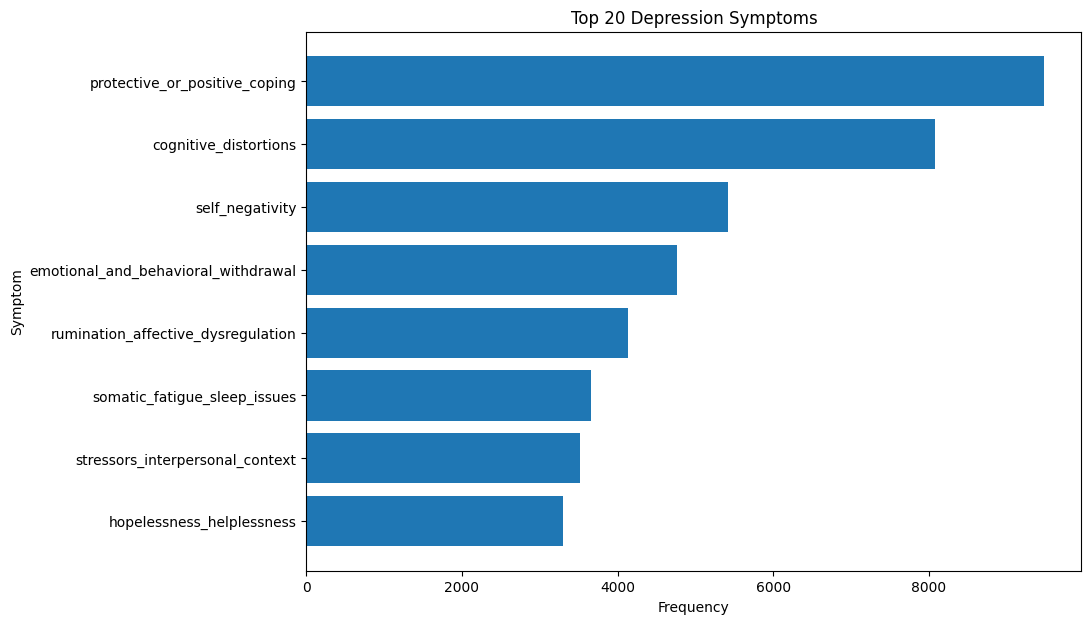

In [ ]:

# STEP 12 : i will now Plot Top all Symptoms


plt.figure(figsize=(10,7))

top20 = label_df.head(20)

plt.barh(top20["Symptom"],
         top20["Frequency"])

plt.xlabel("Frequency")

plt.ylabel("Symptom")

plt.title("Top 20 Depression Symptoms")

plt.gca().invert_yaxis()

plt.show()

In [ ]:

# STEP 13 : Number of Symptoms per Conversation


"""
Each participant response may contain

1 symptom

2 symptoms

3 symptoms

etc.
"""

new_df["Number_of_Labels"] = new_df["labels"].apply(len)

print(new_df["Number_of_Labels"].value_counts())


Number_of_Labels
1    7678
3    5228
2    5129
4    1545
5     390
6      90
7       9
Name: count, dtype: int64


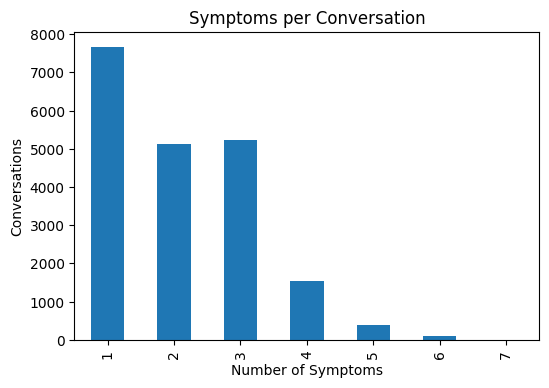

In [ ]:

# STEP 14 : Plot Label Count Distribution


plt.figure(figsize=(6,4))

new_df["Number_of_Labels"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Number of Symptoms")

plt.ylabel("Conversations")

plt.title("Symptoms per Conversation")

plt.show()

In [ ]:



# STEP 15 : Text Length Analysis


"""
Character Length
"""

new_df["Character_Length"] = new_df["participant"].apply(len)

print(new_df["Character_Length"].describe())



# STEP 16 : Word Length Analysis


new_df["Word_Count"] = new_df["participant"].apply(
    lambda x: len(x.split())
)

print(new_df["Word_Count"].describe())

count    20069.000000
mean       120.688275
std         64.898991
min          0.000000
25%         78.000000
50%        112.000000
75%        152.000000
max        687.000000
Name: Character_Length, dtype: float64
count    20069.000000
mean        24.260402
std         22.225365
min          0.000000
25%         14.000000
50%         20.000000
75%         27.000000
max        277.000000
Name: Word_Count, dtype: float64


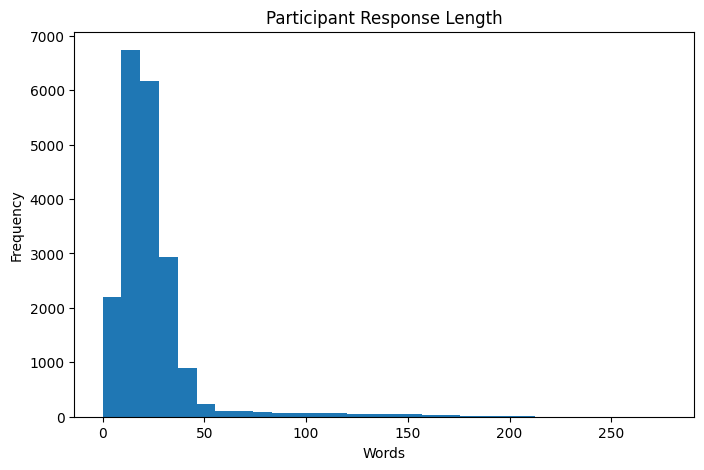

In [ ]:

# STEP 17 : Plot Word Count Distribution


plt.figure(figsize=(8,5))

plt.hist(new_df["Word_Count"],
         bins=30)

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.title("Participant Response Length")

plt.show()

In [ ]:


# STEP 18 : Show Sample Conversation


print("\nExample Input\n")

print(new_df.iloc[0]["participant"])

print("\nCorresponding Labels\n")

print(new_df.iloc[0]["labels"])


# STEP 19 : Save Clean Dataset


"""
Instead of loading 1000 JSON files every time,

save one clean CSV.
"""

new_df.to_csv("/content/drive/MyDrive/mental_health_mendely_dataset/" + "mental_health_clean.csv",
          index=False)

print("\nDataset Saved Successfully")


Example Input

Hey… I’m okay, you know? Just one of those “is it really Monday again?” kind of days.

Corresponding Labels

['somatic_fatigue_sleep_issues', 'rumination_affective_dysregulation']

Dataset Saved Successfully


In [ ]:

# STEP 20 : Summary


print("\n==============================")

print("DATASET SUMMARY")

print("==============================")

print("Total Conversations :", len(new_df))

print("Unique Symptoms :", len(counter))

print("Average Words :", round(new_df["Word_Count"].mean(),2))

print("Average Labels :", round(new_df["Number_of_Labels"].mean(),2))

print("==============================")

print("Phase 1 Completed Successfully")


#After setting up the next phase with a MultiLabelBinarizer and performing a train-test split,
# I will  apply RoBERTa tokenization before fine-tuning the RoBERTa mode



DATASET SUMMARY
Total Conversations : 20069
Unique Symptoms : 11
Average Words : 24.26
Average Labels : 2.11
Phase 1 Completed Successfully


**Phase 2 - Multilabel classification i.e. actual model building phase for multiple symptoms**

In [ ]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load Dataset


dataset_path ="/content/drive/MyDrive/mental_health_mendely_dataset/mental_health_clean.csv"

df = pd.read_csv(dataset_path)
print("dataset loaded successfully")
print(df.shape)


dataset loaded successfully
(20069, 7)


In [ ]:

# Remove Missing Values


df=df.dropna(subset=["participant","labels"])
print("after removing nan values the new shape:",df.shape)

# remove empty text
df = df[df["participant"].str.strip() != ""]

# remove duplicate participant responses

df = df.drop_duplicates(subset=["participant"])

df = df.reset_index(drop=True)

print("Dataset Shape After Cleaning :", df.shape)

# ------------------------------------------------------------
#  i need to Convert Labels String back to Python List
# ------------------------------------------------------------

# CSV stores list as string.
# Convert:
#
# "['a','b']"
#
# into
#
# ['a','b']

df["labels"] = df["labels"].apply(ast.literal_eval)

print("\nExample Labels")

print(df["labels"].head())


after removing nan values the new shape: (19892, 7)
Dataset Shape After Cleaning : (19653, 7)

Example Labels
0    [somatic_fatigue_sleep_issues, rumination_affe...
1    [somatic_fatigue_sleep_issues, rumination_affe...
2    [cognitive_distortions, self_negativity, emoti...
3    [cognitive_distortions, emotional_and_behavior...
4    [cognitive_distortions, stressors_interpersona...
Name: labels, dtype: object


In [ ]:

# Multi Label Binarizer


mlb = MultiLabelBinarizer()

Y = mlb.fit_transform(df["labels"])

print("\nSymptoms Learned By Model\n")

print(mlb.classes_)

print("\nTotal Symptoms :", len(mlb.classes_))


# Create Training Dataframe


processed_df = pd.concat(
    [
        df[["participant"]],
        pd.DataFrame(Y, columns=mlb.classes_)
    ],
    axis=1
)

print("\nProcessed Dataset")

display(processed_df.head())


Symptoms Learned By Model

['cognitive_distortions' 'emotional_and_behavioral_withdrawal'
 'hopelessness_helplessness' 'protective_or_positive_coping'
 'rumination_affective_dysregulation' 'self_negativity'
 'somatic_fatigue_sleep_issues' 'stressors_interpersonal_context']

Total Symptoms : 8

Processed Dataset


,participant,cognitive_distortions,emotional_and_behavioral_withdrawal,hopelessness_helplessness,protective_or_positive_coping,rumination_affective_dysregulation,self_negativity,somatic_fatigue_sleep_issues,stressors_interpersonal_context
0,"Hey… I’m okay, you know? Just one of those “is...",0,0,0,0,1,0,1,0
1,"Nah, nothing huge. I hit snooze three times, t...",0,1,0,0,1,0,1,0
2,"It’s like a quiet narrator, not yelling, just…...",1,1,0,0,0,1,0,0
3,"Distracted, I guess. The irritation’s gone, bu...",1,1,0,0,0,0,0,0
4,"Honestly, just rolling out of bed without the ...",1,1,0,0,0,0,0,1


In [ ]:


#train test validation split - for before classification model building

train_df, temp_df = train_test_split(
    processed_df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

print("\nTraining Samples :", len(train_df))
print("Validation Samples :", len(valid_df))
print("Testing Samples :", len(test_df))



Training Samples : 15722
Validation Samples : 1965
Testing Samples : 1966


In [ ]:

#now i will save procesed files

save_path = "/content/drive/MyDrive/mental_health_mendely_dataset/"

train_df.to_csv(save_path+"train.csv", index=False)

valid_df.to_csv(save_path+"validation.csv", index=False)

test_df.to_csv(save_path+"test.csv", index=False)

print("\nDatasets Saved Successfully")

print("\nFiles Saved")

print("train.csv")

print("validation.csv")

print("test.csv")


Datasets Saved Successfully

Files Saved
train.csv
validation.csv
test.csv


In [ ]:

!pip install -q transformers datasets accelerate evaluate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


In [ ]:

# RoBERTa Multi-Label Classification


import os
import random
import numpy as np
import pandas as pd

# PyTorch

import torch
from torch.utils.data import Dataset, DataLoader

# HuggingFace Transformers

from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification
)

# Display

from tqdm.auto import tqdm

print("All libraries imported successfully!")

# ----------------------------------------------------------
# Check GPU
# ----------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nRunning on :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

All libraries imported successfully!

Running on : cuda
GPU : Tesla T4


In [ ]:
#load train data

dataset_path = "/content/drive/MyDrive/mental_health_mendely_dataset/"

train_df = pd.read_csv(dataset_path + "train.csv")
valid_df = pd.read_csv(dataset_path + "validation.csv")

print("Training Shape :", train_df.shape)
print("Validation Shape :", valid_df.shape)

display(train_df.head())



TEXT_COLUMN = "participant"


label_columns = train_df.columns[1:]

print("\nLabels used by model:\n")

for i, label in enumerate(label_columns):
    print(i+1, ".", label)

print("\nTotal Labels :", len(label_columns))

Training Shape : (15722, 9)
Validation Shape : (1965, 9)


,participant,cognitive_distortions,emotional_and_behavioral_withdrawal,hopelessness_helplessness,protective_or_positive_coping,rumination_affective_dysregulation,self_negativity,somatic_fatigue_sleep_issues,stressors_interpersonal_context
0,Pretty solid. I swapped late-night scrolling f...,0,0,0,1,0,0,0,0
1,"I wake up tired, stare at the ceiling, and won...",0,1,1,0,0,0,1,0
2,"Work, family, everything. I go in circles, not...",0,0,1,0,1,0,0,0
3,Let’s talk about guilt when I take downtime. I...,1,0,0,0,0,1,0,0
4,I’d have to believe I deserve the time. Right ...,1,0,0,0,0,1,0,0



Labels used by model:

1 . cognitive_distortions
2 . emotional_and_behavioral_withdrawal
3 . hopelessness_helplessness
4 . protective_or_positive_coping
5 . rumination_affective_dysregulation
6 . self_negativity
7 . somatic_fatigue_sleep_issues
8 . stressors_interpersonal_context

Total Labels : 8


In [ ]:
#load roberta tokenizer

MODEL_NAME = "roberta-base"

tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer Loaded Successfully")


# Test Tokenizer -- just checking whether it is working properly


sample_text = train_df.iloc[0]["participant"]

encoding = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=256
)

print("\nOriginal Sentence:\n")
print(sample_text)

print("\nLength of input_ids :", len(encoding["input_ids"]))

print("\nFirst 20 Token IDs\n")

print(encoding["input_ids"][:20])

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizer Loaded Successfully

Original Sentence:

Pretty solid. I swapped late-night scrolling for an audiobook timer—Bill Bryson’s voice knocks me out in fifteen minutes flat.

Length of input_ids : 256

First 20 Token IDs

[0, 37396, 2705, 4, 38, 28671, 628, 12, 8498, 33664, 13, 41, 34621, 42581, 35809, 578, 19993, 16360, 1478, 17]


In [ ]:
# custom pytorch dataset

class MentalHealthDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length=256):

        self.dataframe = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):


        # Get Input Text


        text = str(
            self.dataframe.iloc[index]["participant"]
        )


        # Get Labels


        labels = self.dataframe.iloc[index][label_columns].values.astype(np.float32)

        # Tokenization


        encoding = self.tokenizer(

            text,

            padding="max_length",

            truncation=True,

            max_length=self.max_length,

            return_tensors="pt"

        )

        return {

            "input_ids": encoding["input_ids"].squeeze(),

            "attention_mask": encoding["attention_mask"].squeeze(),

            "labels": torch.tensor(labels, dtype=torch.float)

        }

print("Custom Dataset Class Created!")

Custom Dataset Class Created!


In [ ]:
#just to check -----but it was failing previously--testing and checking
# 1. Instantiate the dataset
dataset = MentalHealthDataset(
    dataframe=df,
    tokenizer=tokenizer,
    max_length=256
)

# 2. Fetch the first sample
sample = next(iter(dataset))

# 3. Print the keys and tensor shapes to inspect the output
for key, value in sample.items():
    print(f"**{key}**: Shape -> {value.shape} | Type -> {value.dtype}")

# 4. (Optional) Optional: Decode the input_ids back to text to verify tokenization
print("\n**Decoded Text Sample**:")
print(tokenizer.decode(sample["input_ids"]))


KeyError: "None of [Index(['cognitive_distortions', 'emotional_and_behavioral_withdrawal',\n       'hopelessness_helplessness', 'protective_or_positive_coping',\n       'rumination_affective_dysregulation', 'self_negativity',\n       'somatic_fatigue_sleep_issues', 'stressors_interpersonal_context'],\n      dtype='object')] are in the [index]"

In [ ]:
#data loader

MAX_LENGTH = 256

BATCH_SIZE = 16

train_dataset = MentalHealthDataset(

    train_df,

    tokenizer,

    MAX_LENGTH

)

valid_dataset = MentalHealthDataset(

    valid_df,

    tokenizer,

    MAX_LENGTH

)

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True

)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

print("Train batches :", len(train_loader))

print("Validation batches :", len(valid_loader))

Train batches : 983
Validation batches : 123


In [ ]:

# Cell 6 : RoBERTa Multi-Label Model


NUM_LABELS = len(label_columns)

model = RobertaForSequenceClassification.from_pretrained(

    "roberta-base",

    num_labels=NUM_LABELS,

    problem_type="multi_label_classification"

)

model.to(device)

print(model)

print("\n")

print("Model Loaded Successfully")

print("Number of Symptoms :", NUM_LABELS)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:

#  Optimizer, Scheduler and Training Settings ---create the setup n check


from transformers import get_linear_schedule_with_warmup


# Hyperparameters


EPOCHS = 1

LEARNING_RATE = 2e-5

WEIGHT_DECAY = 0.01


# Optimizer


optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)


# Scheduler


total_training_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(

    optimizer,

    num_warmup_steps=int(0.1 * total_training_steps),

    num_training_steps=total_training_steps

)

print("Optimizer :", optimizer)

print("")

print("Total Training Steps :", total_training_steps)

print("")

print("Learning Rate :", LEARNING_RATE)

print("")

print("Scheduler Loaded Successfully")

Optimizer : AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 2e-05
    lr: 0.0
    maximize: False
    weight_decay: 0.01
)

Total Training Steps : 983

Learning Rate : 2e-05

Scheduler Loaded Successfully


In [ ]:

#  RoBERTa Fine-Tuning - I will finetune it on our dataset


train_losses = []

valid_losses = []

best_validation_loss = float("inf")

for epoch in range(EPOCHS):

    print("="*60)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print("="*60)

    model.train()

    running_loss = 0

    progress_bar = tqdm(train_loader)

    for batch in progress_bar:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask,

            labels=labels

        )

        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=1.0

        )

        optimizer.step()

        scheduler.step()

        running_loss += loss.item()

        progress_bar.set_postfix(

            loss=loss.item()

        )

    average_train_loss = running_loss / len(train_loader)

    train_losses.append(average_train_loss)

    print()

    print("Average Training Loss :", average_train_loss)


    # Validation Loss


    model.eval()

    validation_loss = 0

    with torch.no_grad():

        for batch in valid_loader:

            input_ids = batch["input_ids"].to(device)

            attention_mask = batch["attention_mask"].to(device)

            labels = batch["labels"].to(device)

            outputs = model(

                input_ids=input_ids,

                attention_mask=attention_mask,

                labels=labels

            )

            validation_loss += outputs.loss.item()

    average_validation_loss = validation_loss / len(valid_loader)

    valid_losses.append(average_validation_loss)

    print("Average Validation Loss :", average_validation_loss)

    # Save Best Model -- I will save it the best model after testing


    if average_validation_loss < best_validation_loss:

        best_validation_loss = average_validation_loss

        model.save_pretrained(

            "/content/drive/MyDrive/mental_health_mendely_dataset/best_roberta_model"

        )

        tokenizer.save_pretrained(

            "/content/drive/MyDrive/mental_health_mendely_dataset/best_roberta_model"

        )

        print("Best model saved!")

print("\nTraining Completed Successfully!")

Epoch 1/1


  0%|          | 0/983 [00:00<?, ?it/s]


Average Training Loss : 0.3939103217054602
Average Validation Loss : 0.32542476227613


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved!

Training Completed Successfully!


In [ ]:

# Cell 9 : Validation Metrics


from sklearn.metrics import (

    precision_score,

    recall_score,

    f1_score,

    classification_report

)

model.eval()

all_predictions = []

all_labels = []

THRESHOLD = 0.50

with torch.no_grad():

    for batch in tqdm(valid_loader):

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].cpu().numpy()

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )

        probabilities = torch.sigmoid(

            outputs.logits

        ).cpu().numpy()

        predictions = (

            probabilities >= THRESHOLD

        ).astype(int)

        all_predictions.extend(predictions)

        all_labels.extend(labels)

all_predictions = np.array(all_predictions)

all_labels = np.array(all_labels)


# Metrics


micro_precision = precision_score(

    all_labels,

    all_predictions,

    average="micro"

)

micro_recall = recall_score(

    all_labels,

    all_predictions,

    average="micro"

)

micro_f1 = f1_score(

    all_labels,

    all_predictions,

    average="micro"

)

macro_precision = precision_score(

    all_labels,

    all_predictions,

    average="macro"

)

macro_recall = recall_score(

    all_labels,

    all_predictions,

    average="macro"

)

macro_f1 = f1_score(

    all_labels,

    all_predictions,

    average="macro"

)

print("="*50)

print("Validation Results")

print("="*50)

print()

print(f"Micro Precision : {micro_precision:.4f}")

print(f"Micro Recall    : {micro_recall:.4f}")

print(f"Micro F1 Score  : {micro_f1:.4f}")

print()

print(f"Macro Precision : {macro_precision:.4f}")

print(f"Macro Recall    : {macro_recall:.4f}")

print(f"Macro F1 Score  : {macro_f1:.4f}")

print()

print("="*50)

print("Classification Report")

print("="*50)

print(

    classification_report(

        all_labels,

        all_predictions,

        target_names=label_columns,

        zero_division=0

    )

)

  0%|          | 0/123 [00:00<?, ?it/s]

Validation Results

Micro Precision : 0.7893
Micro Recall    : 0.6430
Micro F1 Score  : 0.7087

Macro Precision : 0.7613
Macro Recall    : 0.5900
Macro F1 Score  : 0.6605

Classification Report
                                     precision    recall  f1-score   support

              cognitive_distortions       0.82      0.73      0.77       794
emotional_and_behavioral_withdrawal       0.71      0.50      0.59       468
          hopelessness_helplessness       0.72      0.42      0.53       320
      protective_or_positive_coping       0.87      0.86      0.86       934
 rumination_affective_dysregulation       0.67      0.51      0.58       380
                    self_negativity       0.74      0.63      0.68       533
       somatic_fatigue_sleep_issues       0.86      0.61      0.72       383
    stressors_interpersonal_context       0.71      0.46      0.56       342

                          micro avg       0.79      0.64      0.71      4154
                          macro av

This above report is just for showing purpose and testing-later I will build Gradio GUI and it can be used as artifact

In [ ]:
#load the saved model

from transformers import RobertaTokenizer, RobertaForSequenceClassification

MODEL_PATH="/content/drive/MyDrive/mental_health_mendely_dataset/best_roberta_model"

tokenizer=RobertaTokenizer.from_pretrained(MODEL_PATH)

model=RobertaForSequenceClassification.from_pretrained(MODEL_PATH)

model.to(device)

model.eval()

print("Model Loaded Successfully")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model Loaded Successfully


In [ ]:
!pip install -q gradio

In [ ]:
import torch
import gradio as gr

# Labels (must be in SAME ORDER as training)

label_names = [
    "cognitive_distortions",
    "emotional_and_behavioral_withdrawal",
    "hopelessness_helplessness",
    "protective_or_positive_coping",
    "rumination_affective_dysregulation",
    "self_negativity",
    "somatic_fatigue_sleep_issues",
    "stressors_interpersonal_context"
]

THRESHOLD = 0.50


def predict_symptoms(text):

    if text.strip()=="":
        return ""

    encoding = tokenizer(

        text,

        return_tensors="pt",

        truncation=True,

        padding=True,

        max_length=256

    )

    input_ids = encoding["input_ids"].to(device)

    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )

        probabilities=torch.sigmoid(outputs.logits).cpu().numpy()[0]

    answer="Predicted Symptoms\n\n"

    detected=False

    for symptom,prob in zip(label_names,probabilities):

        if prob>=THRESHOLD:

            detected=True

            answer += f"{symptom} : {prob:.2%}\n"

    if not detected:

        answer+="No symptom exceeded threshold.\n\n"

        answer+="Highest Probabilities:\n\n"

        top_idx=probabilities.argsort()[-3:][::-1]

        for idx in top_idx:

            answer+=f"{label_names[idx]} : {probabilities[idx]:.2%}\n"

    return answer

In [ ]:
demo = gr.Interface(

    fn=predict_symptoms,

    inputs=gr.Textbox(

        lines=8,

        placeholder="Type patient's conversation here..."

    ),

    outputs=gr.Textbox(

        lines=12,

        label="Predicted Symptoms"

    ),

    title="Mental Health Symptom Detection using RoBERTa",

    description="Enter a patient's text. The model predicts depression-related symptoms with probabilities."

)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://62251e0757dab0a228.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Phase 2 is completed and working fine and tested - done - model building , testing and Gradio GUI**

**Phase 3 - Risk assessment module**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# PHASE 3 : Depression Risk Assessment



import torch
import numpy as np
import pandas as pd

from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification
)



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device :", device)


# Path of Fine-Tuned Model


MODEL_PATH = "/content/drive/MyDrive/mental_health_mendely_dataset/best_roberta_model"


# Load Tokenizer


tokenizer = RobertaTokenizer.from_pretrained(MODEL_PATH)


# Load Model


model = RobertaForSequenceClassification.from_pretrained(MODEL_PATH)

model.to(device)

model.eval()

print("\nModel Loaded Successfully!")

Using Device : cpu


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Model Loaded Successfully!


In [ ]:


# Symptom Labels
#
# I have to Keep EXACTLY the same order used during training.


LABELS = [

    "cognitive_distortions",

    "emotional_and_behavioral_withdrawal",

    "hopelessness_helplessness",

    "protective_or_positive_coping",

    "rumination_affective_dysregulation",

    "self_negativity",

    "somatic_fatigue_sleep_issues",

    "stressors_interpersonal_context"

]

print("\nSymptoms--all symptoms just to print")

for i,label in enumerate(LABELS):

    print(f"{i+1}. {label}")



# Predict Symptoms and Their Probabilities


THRESHOLD = 0.50

def predict_symptoms(text):

    """
    Input:
        Raw patient conversation

    Output:
        Dictionary

        {
            symptom : probability
        }

    """

    encoding = tokenizer(

        text,

        truncation=True,

        padding=True,

        max_length=256,

        return_tensors="pt"

    )

    input_ids = encoding["input_ids"].to(device)

    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )

        probabilities = torch.sigmoid(outputs.logits)

        probabilities = probabilities.cpu().numpy()[0]

    symptom_dict = {}

    for symptom,probability in zip(LABELS,probabilities):

        symptom_dict[symptom] = float(probability)

    return symptom_dict



# Example - testing - just to check whether it works


sample_text = """
I feel energetic every day.

Nothing excites me anymore.

I think I am pretty good and optimistic person.

but I play cricket and feels good sometimes.
"""

prediction = predict_symptoms(sample_text)

print("\nPredicted Symptom Probabilities for sample test\n")

for symptom,prob in prediction.items():

    print(f"{symptom:45s} : {prob:.3f}")


Symptoms--all symptoms just to print
1. cognitive_distortions
2. emotional_and_behavioral_withdrawal
3. hopelessness_helplessness
4. protective_or_positive_coping
5. rumination_affective_dysregulation
6. self_negativity
7. somatic_fatigue_sleep_issues
8. stressors_interpersonal_context

Predicted Symptom Probabilities for sample test

cognitive_distortions                         : 0.539
emotional_and_behavioral_withdrawal           : 0.362
hopelessness_helplessness                     : 0.420
protective_or_positive_coping                 : 0.118
rumination_affective_dysregulation            : 0.158
self_negativity                               : 0.318
somatic_fatigue_sleep_issues                  : 0.213
stressors_interpersonal_context               : 0.036


In [ ]:


# Depression Risk Assessment Module


"""
Clinical Risk Logic

I have estimated an overall depression risk score using
the predicted probabilities.

Depression-related symptoms increase the score.

Protective coping reduces the score.

Formula

Risk Score

=

Mean(

Cognitive Distortions

Withdrawal

Hopelessness

Rumination

Self Negativity

Fatigue

Stressors

)

-

0.50 × Protective Coping

Finally,

Clip score between

0

and

1

Risk Categories

0.00 - 0.30

LOW

0.30 - 0.60

MODERATE

0.60 - 1.00

HIGH

"""


def calculate_risk(symptom_probabilities):

    depression_symptoms = [

        "cognitive_distortions",

        "emotional_and_behavioral_withdrawal",

        "hopelessness_helplessness",

        "rumination_affective_dysregulation",

        "self_negativity",

        "somatic_fatigue_sleep_issues",

        "stressors_interpersonal_context"

    ]

    depression_values = [

        symptom_probabilities[s]

        for s in depression_symptoms

    ]


    # Average Depression Probability


    depression_score = np.mean(depression_values)


    # Protective Coping


    protective = symptom_probabilities["protective_or_positive_coping"]

    # Final Risk Score


    risk_score = depression_score - (0.50 * protective)

    risk_score = float(np.clip(risk_score,0,1))

    # Risk Category


    if risk_score < 0.30:

        category = "LOW RISK"

    elif risk_score < 0.60:

        category = "MODERATE RISK"

    else:

        category = "HIGH RISK"

    return {

        "risk_score":round(risk_score,3),

        "risk_category":category

    }


# Example

risk = calculate_risk(prediction)

print("\n")

print("="*60)

print("DEPRESSION RISK ASSESSMENT for previous sample text i.e depressed person")

print("="*60)

print("Risk Score     :", risk["risk_score"])

print("Risk Category  :", risk["risk_category"])

print("="*60)



DEPRESSION RISK ASSESSMENT for previous sample text i.e depressed person
Risk Score     : 0.233
Risk Category  : LOW RISK


In [ ]:
# generate professional report

from datetime import datetime


def generate_clinical_report(text):
    """
    - Generates a structured clinical report based on:
    - RoBERTa symptom predictions
    - Depression risk assessment

    """



    symptom_predictions = predict_symptoms(text)


    risk = calculate_risk(symptom_predictions)


    report_time = datetime.now().strftime("%d-%m-%Y %H:%M")


    report = ""
    report += "="*70 + "\n"
    report += "      EXPLAINABLE MENTAL HEALTH TRIAGE REPORT\n"
    report += "="*70 + "\n\n"

    report += f"Generated : {report_time}\n\n"

    report += "-"*70 + "\n"
    report += "PATIENT INPUT\n"
    report += "-"*70 + "\n"

    report += text.strip()

    report += "\n\n"

    # Predicted Symptoms


    report += "-"*70 + "\n"
    report += "PREDICTED SYMPTOMS\n"
    report += "-"*70 + "\n"

    sorted_symptoms = sorted(
        symptom_predictions.items(),
        key=lambda x: x[1],
        reverse=True
    )

    detected = False

    for symptom, probability in sorted_symptoms:

        if probability >= THRESHOLD:

            detected = True

            report += f"✓ {symptom:45s} {probability:.2%}\n"

    if not detected:

        report += "No symptom exceeded the prediction threshold.\n"

        report += "\nTop probable symptoms:\n\n"

        for symptom, probability in sorted_symptoms[:3]:

            report += f"• {symptom:45s} {probability:.2%}\n"

    report += "\n"


    # Risk Assessment


    report += "-"*70 + "\n"
    report += "DEPRESSION RISK ASSESSMENT\n"
    report += "-"*70 + "\n"

    report += f"Risk Score     : {risk['risk_score']:.3f}\n"
    report += f"Risk Category  : {risk['risk_category']}\n\n"


    # Confidence


    highest_probability = max(symptom_predictions.values())

    if highest_probability >= 0.90:

        confidence = "HIGH"

    elif highest_probability >= 0.70:

        confidence = "MODERATE"

    else:

        confidence = "LOW"

    report += f"Prediction Confidence : {confidence}\n\n"


    # Interpretation


    report += "-"*70 + "\n"
    report += "INTERPRETATION\n"
    report += "-"*70 + "\n"

    if risk["risk_category"] == "LOW RISK":

        report += (
            "The conversation contains relatively few linguistic "
            "patterns associated with depression. Positive coping "
            "behaviours or emotionally healthy expressions appear "
            "to outweigh depressive indicators.\n\n"
        )

    elif risk["risk_category"] == "MODERATE RISK":

        report += (
            "The conversation contains several depressive indicators "
            "including negative thinking patterns or emotional "
            "distress. Further monitoring or professional screening "
            "may be beneficial.\n\n"
        )

    else:

        report += (
            "The conversation contains multiple strong indicators "
            "associated with depression, including persistent "
            "negative cognition and emotional distress. Clinical "
            "assessment by a qualified mental health professional "
            "is recommended.\n\n"
        )


    # Disclaimer


    report += "-"*70 + "\n"
    report += "DISCLAIMER\n"
    report += "-"*70 + "\n"

    report += (
        "This report is automatically generated by an AI system "
        "trained for research purposes. It is NOT a clinical "
        "diagnosis and should not replace assessment by a qualified "
        "mental health professional.\n\n"
    )

    report += "="*70

    return report


In [ ]:





# Test the Clinical Report Generator


print("\n")
print("="*70)
print("EXAMPLE 1")
print("="*70)

sample_1 = """
I feel hopeless every day.

Nothing makes me happy anymore.

I think I am useless.

I don't even want to leave my room.

Everything feels pointless.
"""

print(generate_clinical_report(sample_1))


print("\n\n")
print("="*70)
print("EXAMPLE 2")
print("="*70)

sample_2 = """
Today was a good day.

I played cricket with my friends.

Although work was stressful,
I still enjoyed the evening.

I am looking forward to tomorrow.
"""

print(generate_clinical_report(sample_2))


print("\n\n")
print("="*70)
print("EXAMPLE 3")
print("="*70)

sample_3 = """
Some days I feel okay.

Other days I overthink everything.

I struggle to sleep sometimes.

But my family supports me and
I am trying to improve.
"""

print(generate_clinical_report(sample_3))



EXAMPLE 1
      EXPLAINABLE MENTAL HEALTH TRIAGE REPORT

Generated : 18-07-2026 14:55

----------------------------------------------------------------------
PATIENT INPUT
----------------------------------------------------------------------
I feel hopeless every day.

Nothing makes me happy anymore.

I think I am useless.

I don't even want to leave my room.

Everything feels pointless.

----------------------------------------------------------------------
PREDICTED SYMPTOMS
----------------------------------------------------------------------
✓ hopelessness_helplessness                     91.28%
✓ emotional_and_behavioral_withdrawal           73.93%
✓ cognitive_distortions                         70.12%
✓ self_negativity                               53.42%

----------------------------------------------------------------------
DEPRESSION RISK ASSESSMENT
----------------------------------------------------------------------
Risk Score     : 0.476
Risk Category  : MODERATE RISK


In [ ]:

#
# Backend Functions for Gradio Interface
#
# This cell assumes that the following already exist:
#
# predict_symptoms()
# calculate_risk()
# generate_clinical_report()
# LABELS
# THRESHOLD



import pandas as pd



# Function 1
# Return all symptom probabilities as a dataframe


def symptom_dataframe(text):

    predictions = predict_symptoms(text)

    df = pd.DataFrame({

        "Symptom": predictions.keys(),

        "Probability": [round(v,4) for v in predictions.values()]

    })

    df["Probability (%)"] = (df["Probability"]*100).round(2)

    df = df.sort_values(

        by="Probability",

        ascending=False

    ).reset_index(drop=True)

    return df




# Only return detected symptoms


def detected_symptoms(predictions):

    detected = []

    for symptom,prob in predictions.items():

        if prob >= THRESHOLD:

            detected.append(

                f"✓ {symptom.replace('_',' ').title()} "
                f"({prob:.2%})"

            )

    if len(detected)==0:

        detected.append("No symptom exceeded threshold.")

    return "\n".join(detected)




# Nicely formatted probabilities


def probability_text(predictions):

    lines=[]

    sorted_predictions = sorted(

        predictions.items(),

        key=lambda x:x[1],

        reverse=True

    )

    for symptom,prob in sorted_predictions:

        lines.append(

            f"{symptom.replace('_',' ').title():45s}"

            f"{prob:.2%}"

        )

    return "\n".join(lines)




# Short Risk Summary


def risk_summary(risk):

    summary=""

    summary+="Risk Score : "

    summary+=str(risk["risk_score"])

    summary+="\n"

    summary+="Risk Level : "

    summary+=risk["risk_category"]

    return summary




# This is the function that Gradio will call.


def analyse_patient(text):

    if text is None or len(text.strip())==0:

        empty_df = pd.DataFrame(

            columns=["Symptom","Probability","Probability (%)"]

        )

        return (

            empty_df,

            "",

            "",

            ""

        )


    # Predict Symptoms


    predictions = predict_symptoms(text)


    # Risk Assessment


    risk = calculate_risk(predictions)


    # DataFrame


    symptom_df = symptom_dataframe(text)




    # Strings


    detected = detected_symptoms(predictions)

    risk_text = risk_summary(risk)

    report = generate_clinical_report(text)



    return (

        symptom_df,

        detected,

        risk_text,

        report

    )



# Small Test - just for checking


sample = """

I feel hopeless.

Nothing makes me happy anymore.

I think everyone would be better without me.

I don't enjoy anything.

"""

df,detected,risk,report = analyse_patient(sample)

print("="*70)
print("Detected Symptoms")
print("="*70)

print(detected)

print("\n")

print("="*70)
print("Risk")
print("="*70)

print(risk)

print("\n")

print("="*70)
print("Top Predictions")
print("="*70)

display(df.head())

print("\n")

print("="*70)
print("Clinical Report")
print("="*70)

print(report)

Detected Symptoms
✓ Cognitive Distortions (75.80%)
✓ Emotional And Behavioral Withdrawal (70.38%)
✓ Hopelessness Helplessness (90.02%)
✓ Self Negativity (66.11%)


Risk
Risk Score : 0.485
Risk Level : MODERATE RISK


Top Predictions


,Symptom,Probability,Probability (%)
0,hopelessness_helplessness,0.9002,90.02
1,cognitive_distortions,0.7580,75.80
2,emotional_and_behavioral_withdrawal,0.7038,70.38
3,self_negativity,0.6611,66.11
4,rumination_affective_dysregulation,0.2122,21.22




Clinical Report
      EXPLAINABLE MENTAL HEALTH TRIAGE REPORT

Generated : 18-07-2026 14:55

----------------------------------------------------------------------
PATIENT INPUT
----------------------------------------------------------------------
I feel hopeless.

Nothing makes me happy anymore.

I think everyone would be better without me.

I don't enjoy anything.

----------------------------------------------------------------------
PREDICTED SYMPTOMS
----------------------------------------------------------------------
✓ hopelessness_helplessness                     90.02%
✓ cognitive_distortions                         75.80%
✓ emotional_and_behavioral_withdrawal           70.38%
✓ self_negativity                               66.11%

----------------------------------------------------------------------
DEPRESSION RISK ASSESSMENT
----------------------------------------------------------------------
Risk Score     : 0.485
Risk Category  : MODERATE RISK

Prediction Confidence

**Gradio GUI without RAG --- tested and worked**

i.e

Here i have done without RAG and without XAI:--
1.   symptom detection with scores
2.   Risk score and risk level
3.   Top predictions
4.   In report format
5.   Interpretation and disclamer -- which is general --later I will do using XAI





In [ ]:

# Gradio Interface
#
# Requires:
# analyse_patient()


import gradio as gr



theme = gr.themes.Soft()


with gr.Blocks(theme=theme, title="Explainable Mental Health Triage System") as demo:

    gr.Markdown(
        """
#  Explainable Mental Health Triage System

### Multi-Label RoBERTa Classification + Risk Assessment

Enter a patient's conversation below and click **Analyse**.

The system predicts:

- Depression symptoms
- Symptom probabilities
- Depression risk score
- Risk category
- Professional AI-generated clinical report

---
"""
    )

    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    with gr.Row():

        patient_input = gr.Textbox(

            label="Patient Conversation",

            placeholder="Type or paste a patient's conversation here...",

            lines=10

        )


    with gr.Row():

        analyse_btn = gr.Button(

            "🔍 Analyse",

            variant="primary"

        )

        clear_btn = gr.Button(

            "🗑 Clear"

        )


    with gr.Row():

        symptom_table = gr.Dataframe(

            label="Predicted Symptom Probabilities",

            interactive=False

        )

    with gr.Row():

        detected_box = gr.Textbox(

            label="Detected Symptoms",

            lines=8,

            interactive=False

        )

        risk_box = gr.Textbox(

            label="Depression Risk Assessment",

            lines=8,

            interactive=False

        )

    with gr.Row():

        report_box = gr.Textbox(

            label="Professional Clinical Report",

            lines=25,

            interactive=False

        )



    analyse_btn.click(

        fn=analyse_patient,

        inputs=patient_input,

        outputs=[

            symptom_table,

            detected_box,

            risk_box,

            report_box

        ]

    )



    patient_input.change(

        fn=analyse_patient,

        inputs=patient_input,

        outputs=[

            symptom_table,

            detected_box,

            risk_box,

            report_box

        ]

    )



    clear_btn.click(

        lambda: ("", None, "", "", ""),

        outputs=[

            patient_input,

            symptom_table,

            detected_box,

            risk_box,

            report_box

        ]

    )



demo.launch(
    debug=True,
    share=True
)

/tmp/ipykernel_569/1338401100.py:23: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=theme, title="Explainable Mental Health Triage System") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://dc7b661e36d8795c01.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://dc7b661e36d8795c01.gradio.live


**Phase 4: RAG - NICE GUIDELINES - FAISS DATABASE**

Here I will use RAG and NICE guidelines suggested by UK care science lab where
I can upload the pdf and create the chunks.
Then I can have a vector embeddings for them and later I can create vector db FAISS to store them
and we will retrive the relevent data by using cosine similarity , so that
only relevent chunks can be gotten

In [ ]:
!pip -q install pymupdf sentence-transformers faiss-cpu

In [ ]:




import fitz
import re
import pickle
import textwrap
from pathlib import Path

print("Libraries Imported Successfully")




#from google.colab import drive
#drive.mount('/content/drive')






PDF_PATH = "/content/drive/MyDrive/saisudha_Agentic_RAG_project/NICE_guidelines.pdf"

doc = fitz.open(PDF_PATH)

#print("="*60)
print("PDF Loaded Successfully")
print("Number of Pages :", len(doc))
#print("="*60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 44.2 MB/s eta 0:00:00
Libraries Imported Successfully
PDF Loaded Successfully
Number of Pages : 111


In [ ]:

# Extract Text From Every Page


all_text = ""

for page_number in range(len(doc)):

    page = doc.load_page(page_number)

    text = page.get_text()

    all_text += text + "\n"

print("Total Characters Extracted :", len(all_text))



#  Clean the Text


def clean_text(text):

    # remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    # remove repeated blank lines
    text = re.sub(r"\n+", "\n", text)

    # remove page numbers like "Page 23"
    text = re.sub(r"Page\s+\d+", "", text)

    # remove isolated page digits
    text = re.sub(r"\n\d+\n", "\n", text)

    # remove long spaces
    text = re.sub(r" +", " ", text)

    return text.strip()


clean_document = clean_text(all_text)

print("Cleaned Text Length :", len(clean_document))

Total Characters Extracted : 176917
Cleaned Text Length : 172203


In [ ]:



# Smart Semantic Chunking


"""
Instead of cutting every 500 characters,
we preserve paragraph boundaries.

Each chunk contains approximately
350-500 words.

This improves retrieval quality.
"""

paragraphs = clean_document.split(". ")

paragraphs = [p.strip() for p in paragraphs if len(p.strip()) > 20]

print("Total Paragraphs :", len(paragraphs))


chunks = []

current_chunk = ""

current_word_count = 0

TARGET_WORDS = 450


for paragraph in paragraphs:

    words = len(paragraph.split())

    if current_word_count + words <= TARGET_WORDS:

        current_chunk += paragraph + ". "

        current_word_count += words

    else:

        chunks.append(current_chunk.strip())

        current_chunk = paragraph + ". "

        current_word_count = words


if len(current_chunk) > 0:

    chunks.append(current_chunk.strip())


#print("="*60)
print("Semantic Chunking Complete")
print("Total Chunks :", len(chunks))
#print("="*60)


#  Remove Duplicate Chunks


unique_chunks = []

seen = set()

for chunk in chunks:

    cleaned = chunk.strip()

    if cleaned not in seen:

        seen.add(cleaned)

        unique_chunks.append(cleaned)

chunks = unique_chunks

print("Unique Chunks :", len(chunks))



#  Display Sample Chunks


print("="*70)
print("FIRST CHUNK")
print("="*70)

print(textwrap.fill(chunks[0][:1500], width=100))

print("\n\n")

print("="*70)
print("SECOND CHUNK")
print("="*70)

print(textwrap.fill(chunks[1][:1500], width=100))

Total Paragraphs : 977
Semantic Chunking Complete
Total Chunks : 57
Unique Chunks : 57
FIRST CHUNK
Depression in adults: treatment and management NICE guideline Published: 29 June 2022
www.nice.org.uk/guidance/ng222 © NICE 2026. Subject to Notice of rights
(https://www.nice.org.uk/terms-and- conditions#notice-of-rights). Your responsibility The
recommendations in this guideline represent the view of NICE, arrived at after careful consideration
of the evidence available. When exercising their judgement, professionals and practitioners are
expected to take this guideline fully into account, alongside the individual needs, preferences and
values of their patients or the people using their service. It is not mandatory to apply the
recommendations, and the guideline does not override the responsibility to make decisions
appropriate to the circumstances of the individual, in consultation with them and their families and
carers or guardian. All problems (adverse events) related to a medicine 

In [ ]:

#  Save Chunks


OUTPUT_PATH = "/content/drive/MyDrive/saisudha_Agentic_RAG_project/chunks.pkl"

with open(OUTPUT_PATH, "wb") as f:

    pickle.dump(chunks, f)

print("="*60)
print("Chunks Saved Successfully")
print(OUTPUT_PATH)
print("="*60)



# Statistics


lengths = [len(chunk.split()) for chunk in chunks]

print("\nKnowledge Base Statistics")
print("-"*50)

print("Number of Chunks :", len(chunks))
print("Average Words :", round(sum(lengths)/len(lengths),2))
print("Maximum Words :", max(lengths))
print("Minimum Words :", min(lengths))



#  Quick Search Test


keyword = "depression"

results = []

for chunk in chunks:

    if keyword.lower() in chunk.lower():

        results.append(chunk)

print("\nChunks containing word 'depression' :", len(results))

if len(results) > 0:

    print("\nExample Chunk:\n")

    print(textwrap.fill(results[0][:1200], width=100))



Chunks Saved Successfully
/content/drive/MyDrive/saisudha_Agentic_RAG_project/chunks.pkl

Knowledge Base Statistics
--------------------------------------------------
Number of Chunks : 57
Average Words : 424.35
Maximum Words : 450
Minimum Words : 275

Chunks containing word 'depression' : 57

Example Chunk:

Depression in adults: treatment and management NICE guideline Published: 29 June 2022
www.nice.org.uk/guidance/ng222 © NICE 2026. Subject to Notice of rights
(https://www.nice.org.uk/terms-and- conditions#notice-of-rights). Your responsibility The
recommendations in this guideline represent the view of NICE, arrived at after careful consideration
of the evidence available. When exercising their judgement, professionals and practitioners are
expected to take this guideline fully into account, alongside the individual needs, preferences and
values of their patients or the people using their service. It is not mandatory to apply the
recommendations, and the guideline does not overrid

**RUN for directly saved chunks**

I have saved the chunks.pkl file and it can be used directly

In [ ]:


# Create Sentence Embeddings
# Build FAISS Vector Database
# Save FAISS Index
# Test Semantic Retrieval


import pickle
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

print("="*60)
print("Loading chunks.pkl ...")
print("="*60)


# STEP 1 : Load Chunks


CHUNK_PATH = "/content/drive/MyDrive/saisudha_Agentic_RAG_project/chunks.pkl"

with open(CHUNK_PATH, "rb") as f:
    chunks = pickle.load(f)

print(f"Total Chunks Loaded : {len(chunks)}")


# STEP 2 : Load Embedding Model


print("\nLoading SentenceTransformer Model...")

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Model Loaded Successfully!")

print("\nEmbedding Dimension:",
      embedding_model.get_sentence_embedding_dimension())



# STEP 3 : Generate Embeddings


print("\nGenerating embeddings...")
print("This may take 30-60 seconds...")

embeddings = embedding_model.encode(

    chunks,

    batch_size=32,

    show_progress_bar=True,

    convert_to_numpy=True,

    normalize_embeddings=True

)

print("\nEmbedding Shape :", embeddings.shape)

print("Example Vector Length :", len(embeddings[0]))

Loading chunks.pkl ...
Total Chunks Loaded : 57

Loading SentenceTransformer Model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model Loaded Successfully!

Embedding Dimension: 384

Generating embeddings...
This may take 30-60 seconds...


/tmp/ipykernel_569/2124841349.py:43: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_model.get_sentence_embedding_dimension())


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


Embedding Shape : (57, 384)
Example Vector Length : 384


In [ ]:




# STEP 4 : Create FAISS Index


dimension = embeddings.shape[1]

print("\nEmbedding Dimension :", dimension)

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("\nFAISS Index Created!")

print("Vectors Stored :", index.ntotal)


# Save FAISS Index


INDEX_PATH = "/content/drive/MyDrive/saisudha_Agentic_RAG_project/faiss.index"

faiss.write_index(index, INDEX_PATH)

print("\nFAISS Index Saved!")

print(INDEX_PATH)



# STEP 6 : Save Embeddings


EMBEDDING_PATH = "/content/drive/MyDrive/saisudha_Agentic_RAG_project/embeddings.npy"

np.save(EMBEDDING_PATH, embeddings)

print("\nEmbeddings Saved!")

print(EMBEDDING_PATH)



# STEP 7 : Save Chunks Again


CHUNK_SAVE = "/content/drive/MyDrive/saisudha_Agentic_RAG_project/chunks.pkl"

with open(CHUNK_SAVE,"wb") as f:
    pickle.dump(chunks,f)

print("\nChunks Saved Again")




Embedding Dimension : 384

FAISS Index Created!
Vectors Stored : 57

FAISS Index Saved!
/content/drive/MyDrive/saisudha_Agentic_RAG_project/faiss.index

Embeddings Saved!
/content/drive/MyDrive/saisudha_Agentic_RAG_project/embeddings.npy

Chunks Saved Again


In [ ]:


# STEP 8 : Semantic Search Function


def retrieve_chunks(query, top_k=3):

    query_embedding = embedding_model.encode(

        [query],

        normalize_embeddings=True,

        convert_to_numpy=True

    )

    distances, indices = index.search(

        query_embedding,

        top_k

    )

    retrieved = []

    for rank, idx in enumerate(indices[0]):

        retrieved.append({

            "Rank": rank+1,

            "Distance": float(distances[0][rank]),

            "Chunk": chunks[idx]

        })

    return retrieved



In [ ]:


# STEP 9 : Test Retrieval


query = """

patient has insomnia, anxiety and lives in social isolation.

"""

results = retrieve_chunks(query, top_k=3)

print("\n")
print("="*80)
print("Semantic Retrieval Results")
print("="*80)

for result in results:

    print("\n")

    print("="*60)

    print("Rank :", result["Rank"])

    print("Distance :", round(result["Distance"],4))

    print("="*60)

    print(result["Chunk"][:1500])

    print("\n")



# STEP 10 : Statistics


print("\n")
print("="*60)
print("Knowledge Base Summary")
print("="*60)

print("Embedding Model : all-MiniLM-L6-v2")

print("Embedding Size  :", dimension)

print("Total Chunks    :", len(chunks))

print("FAISS Vectors   :", index.ntotal)

print("\nRetriever Ready!")



Semantic Retrieval Results


Rank : 1
Distance : 1.0927
of 111 Avoidance An unhelpful form of coping behaviour in which a person changes their behaviour to avoid thinking about, feeling or doing difficult things. This includes putting things off, reducing activities, not tackling problems, not speaking up for oneself, distraction and using alcohol or substances to numb feelings. Chronic depressive symptoms People with chronic depressive symptoms includes those who continually meet criteria for the diagnosis of a major depressive episode for at least 2 years, or have persistent subthreshold symptoms for at least 2 years, or who have persistent low mood with or without concurrent episodes of major depression for at least 2 years. People with depressive symptoms may also have a number of social and personal difficulties that contribute to the maintenance of their chronic depressive symptoms. Collaborative care Collaborative care requires that the service user and healthcare professional

Just to see how text chunks and corresponding vector embeddings look like: in FAISS database but using google colab data tables

In [ ]:
# here we can see how the output looks like as FAISS output using google colab data_table
# i.e how the chunks and their corresponding text embeddings look like

import pandas as pd
import numpy as np
from google.colab import data_table

# 1. Format data into a relational table layout
df_viewer = pd.DataFrame({
    "Row_ID": range(len(chunks)),
    "Text_Chunk_Content": chunks,
    # Slices the 384-dimension vector to display only the first 4 numbers for clean viewing
    "Embedding_Vector": [f"[{', '.join([f'{v:.4f}' for v in vec[:4]])}, ...]" for vec in embeddings]
})

# 2. Activate the interactive Google Colab grid interface
data_table.enable_dataframe_formatter()
data_table.DataTable(
    df_viewer,
    include_index=False,
    num_rows_per_page=10,
    max_columns=3
)

# this is how my output looks like using google colabs - data tables etc

,Row_ID,Text_Chunk_Content,Embedding_Vector
0,0,Depression in adults: treatment and management...,"[-0.0548, 0.0985, 0.0027, -0.0067, ...]"
1,1,93 Starting and stopping antidepressants ........,"[-0.0171, 0.0333, -0.0364, 0.0221, ...]"
2,2,of 111 Definitions of depression and severity ...,"[0.0398, 0.0059, 0.0131, 0.0511, ...]"
3,3,"[2009, amended 2022] 1.1.4 Advise people with ...","[0.0052, 0.0593, 0.0168, 0.0678, ...]"
4,4,"Also, take into account both the degree of fun...","[-0.0256, 0.0287, -0.0228, 0.0642, ...]"
5,5,"[2009, amended 2022] 1.2.12 If a person with d...","[0.0186, -0.0082, -0.0126, -0.0187, ...]"
6,6,[2022] 1.3.2 Help build a trusting relationshi...,"[-0.0597, 0.0196, -0.0016, 0.0226, ...]"
7,7,For people with depression: • who also have le...,"[-0.0217, -0.0143, -0.0402, 0.0988, ...]"
8,8,"[2009, amended 2022] 1.4.8 When delivering psy...","[-0.0169, 0.0683, 0.0220, 0.0156, ...]"
9,9,"of 111 going to work, within 4 weeks) • when t...","[0.0308, 0.0055, 0.0116, 0.0051, ...]"


In [ ]:
!pip -q install pymupdf sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 78.0 MB/s eta 0:00:00


In [ ]:
# STEP 2 : Mount Google Drive


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import fitz
import re
import pickle
import textwrap
from pathlib import Path

print("Libraries Imported Successfully")



# IMPORT LIBRARIES


import pickle
import faiss
import numpy as np
import torch

from transformers import RobertaTokenizer, RobertaForSequenceClassification
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import MultiLabelBinarizer

print("libraries loaded")

Libraries Imported Successfully
libraries loaded


In [ ]:
# I need to make .pkl file as it is needed
import pandas as pd
import pickle
from sklearn.preprocessing import MultiLabelBinarizer

# Load your processed dataset
df = pd.read_csv("/content/drive/MyDrive/mental_health_mendely_dataset/train.csv")

# These are the label columns used for training
label_columns = [
    "cognitive_distortions",
    "emotional_and_behavioral_withdrawal",
    "hopelessness_helplessness",
    "protective_or_positive_coping",
    "rumination_affective_dysregulation",
    "self_negativity",
    "somatic_fatigue_sleep_issues",
    "stressors_interpersonal_context"
]

# Create an MLB with the correct class order
mlb = MultiLabelBinarizer(classes=label_columns)

# Fit it (just establishes the mapping)
mlb.fit([label_columns])

# Save it
with open("/content/drive/MyDrive/saisudha_Agentic_RAG_project/mlb.pkl", "wb") as f:
    pickle.dump(mlb, f)

print("mlb.pkl saved successfully!")
print("Classes:", mlb.classes_)

mlb.pkl saved successfully!
Classes: ['cognitive_distortions' 'emotional_and_behavioral_withdrawal'
 'hopelessness_helplessness' 'protective_or_positive_coping'
 'rumination_affective_dysregulation' 'self_negativity'
 'somatic_fatigue_sleep_issues' 'stressors_interpersonal_context']


# **----It is running good from here start to end--testing done-it is working good so far  - ALL models m pkl files loaded n run so far it is working good-----**

## **Loading all the pkl files and models from here for RAG without XAI**

I have loaded roberta model, chunks.pkl,
faiss.index db etc

Let me start - running from here

In [1]:
!pip -q install pymupdf sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 60.9 MB/s eta 0:00:00


In [13]:

import fitz
import re
import pickle
import textwrap
from pathlib import Path

print("Libraries Imported Successfully")




import pickle
import faiss
import numpy as np
import torch

from transformers import RobertaTokenizer, RobertaForSequenceClassification
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import MultiLabelBinarizer

print("libraries loaded")

Libraries Imported Successfully
libraries loaded


In [14]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Running on :", device)




ROBERTA_MODEL_PATH = "/content/drive/MyDrive/mental_health_mendely_dataset/best_roberta_model"

MLB_PATH = "/content/drive/MyDrive/saisudha_Agentic_RAG_project/mlb.pkl"

FAISS_INDEX_PATH = "/content/drive/MyDrive/saisudha_Agentic_RAG_project/faiss.index"

CHUNKS_PATH = "/content/drive/MyDrive/saisudha_Agentic_RAG_project/chunks.pkl"

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"




print("\nLoading RoBERTa Tokenizer...")

tokenizer = RobertaTokenizer.from_pretrained(ROBERTA_MODEL_PATH)

print("Tokenizer Loaded.")



# LOAD TRAINED ROBERTA MODEL


print("\nLoading Trained RoBERTa Model...")

model = RobertaForSequenceClassification.from_pretrained(
    ROBERTA_MODEL_PATH
)

model.to(device)

model.eval()

print("RoBERTa Model Loaded Successfully.")


# LOAD MULTILABEL BINARIZER


print("\nLoading MultiLabelBinarizer...")

with open(MLB_PATH,"rb") as f:
    mlb = pickle.load(f)

print("Labels Loaded:")

print(mlb.classes_)


# LOAD SENTENCE TRANSFORMER


print("\nLoading SentenceTransformer...")

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL
)

print("SentenceTransformer Ready.")

# LOAD FAISS INDEX


print("\nLoading FAISS Index...")

index = faiss.read_index(FAISS_INDEX_PATH)

print("Vectors inside FAISS :", index.ntotal)



# LOAD NICE CHUNKS


print("\nLoading NICE Guideline Chunks...")

with open(CHUNKS_PATH,"rb") as f:
    chunks = pickle.load(f)

print("Total Chunks :",len(chunks))

print("\nSystem Ready.")


Running on : cuda

Loading RoBERTa Tokenizer...
Tokenizer Loaded.

Loading Trained RoBERTa Model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RoBERTa Model Loaded Successfully.

Loading MultiLabelBinarizer...
Labels Loaded:
['cognitive_distortions' 'emotional_and_behavioral_withdrawal'
 'hopelessness_helplessness' 'protective_or_positive_coping'
 'rumination_affective_dysregulation' 'self_negativity'
 'somatic_fatigue_sleep_issues' 'stressors_interpersonal_context']

Loading SentenceTransformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SentenceTransformer Ready.

Loading FAISS Index...
Vectors inside FAISS : 57

Loading NICE Guideline Chunks...
Total Chunks : 57

System Ready.


In [16]:


def retrieve_evidence(patient_text,
                      predicted_symptoms,
                      risk_level,
                      top_k=3):
    """
    Retrieve the most relevant NICE guideline passages.

    Parameters
    ----------
    patient_text : str

    predicted_symptoms : list

    risk_level : str

    top_k : int
    """
    # Build semantic search query


    query = f"""

    Patient Conversation:

    {patient_text}

    Predicted Symptoms:

    {", ".join(predicted_symptoms)}

    Predicted Risk Level:

    {risk_level}

    Relevant NICE Depression Guideline

    """

    # Convert query into embedding


    query_embedding = embedding_model.encode(

        [query],

        convert_to_numpy=True,

        normalize_embeddings=True

    )


    # Search FAISS


    distances, indices = index.search(

        query_embedding,

        top_k

    )

    retrieved_chunks = []

    for rank, idx in enumerate(indices[0]):

        retrieved_chunks.append({

            "Rank": rank + 1,

            "Distance": float(distances[0][rank]),

            "Evidence": chunks[idx]

        })

    return retrieved_chunks


In [17]:



# OPTIONAL FUNCTION
# Nicely display retrieved  -- just I will check


def print_retrieved_evidence(results):

    print("\n")

    print("="*90)

    print("RETRIEVED NICE GUIDELINE EVIDENCE")

    print("="*90)

    for item in results:

        print("\n")

        print("-"*70)

        print(f"Rank      : {item['Rank']}")

        print(f"Distance  : {item['Distance']:.4f}")

        print("-"*70)

        print(item["Evidence"][:1500])

        print("\n")


In [18]:



sample_patient = """

I cannot sleep.

Nothing makes me happy anymore.

I feel worthless.

I avoid meeting people.

"""

sample_symptoms = ['cognitive_distortions' 'emotional_and_behavioral_withdrawal'
 'hopelessness_helplessness' 'protective_or_positive_coping'
 'rumination_affective_dysregulation' 'self_negativity'
 'somatic_fatigue_sleep_issues' 'stressors_interpersonal_context']

sample_risk = "HIGH RISK"


results = retrieve_evidence(

    patient_text=sample_patient,

    predicted_symptoms=sample_symptoms,

    risk_level=sample_risk,

    top_k=3

)

print_retrieved_evidence(results)

print("\n")

print("="*70)
print("Retriever Working Successfully.")
print("="*70)



RETRIEVED NICE GUIDELINE EVIDENCE


----------------------------------------------------------------------
Rank      : 1
Distance  : 0.7000
----------------------------------------------------------------------
The 9 symptoms are: • depressed mood – indicated by subjective report or observation by others • loss of interest or pleasure in almost all activities – indicated by subjective report or observation by others • significant (more than 5% in a month) unintentional weight loss or gain or decrease or increase in appetite • sleep disturbance (insomnia or hypersomnia) • psychomotor changes (agitation or retardation) severe enough to be observable by others • tiredness, fatigue, or low energy, or decreased efficiency with which routine tasks are completed • a sense of worthlessness or excessive, inappropriate, or delusional guilt (not merely self-reproach or guilt about being sick) • impaired ability to think, concentrate, or make decisions – indicated by subjective report or observa

In [19]:

# TEST COMPLETE RETRIEVAL PIPELINE--just to check if it is working properly



import torch
import numpy as np


# Predict Symptoms from Patient Conversation

def predict_symptoms(text, threshold=0.50):

    encoded = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():

        outputs = model(**encoded)

        probabilities = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    predicted = []

    for symptom, probability in zip(mlb.classes_, probabilities):

        if probability >= threshold:

            predicted.append(symptom)

    return predicted, probabilities



# Risk Score


def calculate_risk(probabilities):

    risk_score = float(np.mean(probabilities))

    if risk_score >= 0.70:

        risk_level = "HIGH RISK"

    elif risk_score >= 0.40:

        risk_level = "MODERATE RISK"

    else:

        risk_level = "LOW RISK"

    return risk_score, risk_level



# Display Everything Nicely


def run_pipeline(patient_text):

    print("\n")
    print("="*90)
    print("PATIENT CONVERSATION")
    print("="*90)

    print(patient_text)

    print("\n")


    # Prediction


    predicted_symptoms, probabilities = predict_symptoms(patient_text)

    risk_score, risk_level = calculate_risk(probabilities)

    print("="*90)
    print("PREDICTED SYMPTOMS")
    print("="*90)

    if len(predicted_symptoms)==0:

        print("No symptoms predicted.")

    else:

        for symptom in predicted_symptoms:

            print("✓",symptom)

    print("\n")

    print("="*90)
    print("RISK ASSESSMENT")
    print("="*90)

    print(f"Risk Score : {risk_score:.3f}")

    print(f"Risk Level : {risk_level}")

    print("\n")


    # Retrieval


    evidence = retrieve_evidence(

        patient_text=patient_text,

        predicted_symptoms=predicted_symptoms,

        risk_level=risk_level,

        top_k=3

    )

    print("="*90)
    print("TOP RETRIEVED NICE GUIDELINE EVIDENCE")
    print("="*90)

    for item in evidence:

        print("\n")

        print("-"*80)

        print(f"Rank : {item['Rank']}")

        print(f"Distance : {item['Distance']:.4f}")

        print("-"*80)

        print(item["Evidence"][:1200])

        print("\n")

    print("="*90)
    print("PIPELINE SUCCESSFULLY EXECUTED")
    print("="*90)

    return {

        "Symptoms": predicted_symptoms,

        "Probabilities": probabilities,

        "Risk Score": risk_score,

        "Risk Level": risk_level,

        "Evidence": evidence

    }



In [20]:


# TEST EXAMPLE - testing the example


patient = """

I cannot sleep anymore.

Nothing makes me happy.

I feel completely worthless.

I don't want to meet my friends.

Sometimes I feel there is no point in trying.

"""

result = run_pipeline(patient)



PATIENT CONVERSATION


I cannot sleep anymore.

Nothing makes me happy.

I feel completely worthless.

I don't want to meet my friends.

Sometimes I feel there is no point in trying.




PREDICTED SYMPTOMS
✓ cognitive_distortions
✓ emotional_and_behavioral_withdrawal
✓ hopelessness_helplessness


RISK ASSESSMENT
Risk Score : 0.428
Risk Level : MODERATE RISK


TOP RETRIEVED NICE GUIDELINE EVIDENCE


--------------------------------------------------------------------------------
Rank : 1
Distance : 0.6953
--------------------------------------------------------------------------------
The 9 symptoms are: • depressed mood – indicated by subjective report or observation by others • loss of interest or pleasure in almost all activities – indicated by subjective report or observation by others • significant (more than 5% in a month) unintentional weight loss or gain or decrease or increase in appetite • sleep disturbance (insomnia or hypersomnia) • psychomotor changes (agitation or retard

# **I have used  qwen 2.5 /0.5 B model for generating rational and report n summary using the outputs n RAG**

*we are taking new approach modified CPU for backend for pytorch*

In [10]:
pip install --upgrade "optimum-intel[openvino]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.0/795.0 kB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.9/160.9 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 134.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.0/415.0 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.8.0
    Uninstalling safetensors-0.8.0:

In [21]:

# MODIFIED BLOCK 4 - CPU OPTIMIZED OPEN-VINO ENGINE


import torch
from transformers import AutoTokenizer
from optimum.intel import OVModelForCausalLM  # High-performance CPU engine

print("Loading optimized CPU model engine...")
llm_model_name = "Qwen/Qwen2.5-0.5B-Instruct"

# Load the standard tokenizer
llm_tokenizer = AutoTokenizer.from_pretrained(llm_model_name)

# Load via OpenVINO. export=True converts the model dynamically
# and compiles it directly into optimized CPU instructions.
llm_model = OVModelForCausalLM.from_pretrained(
    llm_model_name,
    export=True,
    compile=True,
    device="CPU"
)

if llm_tokenizer.pad_token_id is None:
    llm_tokenizer.pad_token_id = llm_tokenizer.eos_token_id

print("Optimized CPU LLM Engine Ready!")

Loading optimized CPU model engine...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/cache_utils.py:131: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if not self.is_initialized or self.keys.numel() == 0:
/usr/local/lib/python3.12/dist-packages/transformers/masking_utils.py:192: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if (padding_length := kv_length + kv_offset - attention_mask.shape[-1]) > 0:
/usr/local/lib/python3.12/dist-packages/optimum/exporters/openvino/patching_utils.py:230: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely igno

Optimized CPU LLM Engine Ready!


In [22]:


# ------------------------------------------------------------
# 1. Fast CPU Prompt Builder
# ------------------------------------------------------------
def build_clinical_rag_prompt(patient_text, pipeline_results):
    symptoms = pipeline_results.get("Symptoms", [])
    risk_score = pipeline_results.get("Risk Score", 0.0)
    risk_level = pipeline_results.get("Risk Level", "UNKNOWN")
    evidence_list = pipeline_results.get("Evidence", [])

    symptom_summary = "".join([f"- {sym}\n" for sym in symptoms]) if symptoms else "- No major symptoms flagged."

    formatted_evidence = ""
    for item in evidence_list:
        formatted_evidence += f"[START EVIDENCE RANK {item['Rank']}]\n{item['Evidence'].strip()}\n[END EVIDENCE]\n\n"

    system_instruction = (
        "You are a strict clinical report generator. Your task is to explain the classifier's outputs using ONLY the provided evidence.\n"
        "CRITICAL RULES:\n"
        "1. Do NOT list any symptoms for the patient unless they are explicitly present in the 'PATIENT CONVERSATION TRACE' or 'CLASSIFIER PREDICTIONS' below.\n"
        "2. Do NOT copy symptoms from the retrieved NICE guidelines and attribute them to the patient.\n"
        "3. Keep the output concise, objective, and factual."
    )

    user_content = f"""[CONTEXT DATA]
    PATIENT CONVERSATION: "{patient_text}"
    CLASSIFIER PREDICTIONS:
    {symptom_summary}
    METRICS:
    - Risk Score: {risk_score:.4f}
    - Risk Level: {risk_level}

    RETRIEVED NICE GUIDELINES:
    {formatted_evidence}
    [END CONTEXT DATA]

    INSTRUCTION: Using ONLY the data within [CONTEXT DATA], generate the final report in this exact layout:

    - **Clinical Summary:** (Contextualize ONLY the actual text the patient said and the classifier predictions. Do not add outside symptoms.)
    - **Risk Rationale:** (Justify why the risk score {risk_score:.4f} maps to {risk_level} according to the guidelines.)
    - **Action Plan:** (State next steps mapping directly to the retrieved guidelines. Use citations like [Rank X].)
    """

    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": user_content}
    ]

    return llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


In [23]:

# 2. Fast CPU Inference Function
def generate_clinical_explanation(patient_text, pipeline_results):
    prompt = build_clinical_rag_prompt(patient_text, pipeline_results)

    # Simple CPU tokenization
    inputs = llm_tokenizer(prompt, return_tensors="pt")

    # Super-fast optimized CPU token generation loop
    with torch.no_grad():
        generated_ids = llm_model.generate(
            **inputs,
            max_new_tokens=250,  # Lowered slightly for lightning-fast CPU responses
            do_sample=False,
            pad_token_id=llm_tokenizer.eos_token_id
        )

    input_length = inputs["input_ids"].shape[1]
    generated_ids = generated_ids[0][input_length:]

    return llm_tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

# final rag pipeline function to check
def run_complete_rag_pipeline(patient_text):
    pipeline_output = run_pipeline(patient_text)

    print("\n" + "="*90)
    print("GENERATING GROUNDED CLINICAL REPORT (FAST CPU ENGINE)")
    print("="*90)

    clinical_explanation = generate_clinical_explanation(patient_text, pipeline_output)

    print(clinical_explanation)
    print("\n" + "="*90)
    print("COMPLETE RAG PIPELINE EXECUTED SUCCESSFULLY")
    print("="*90)

    pipeline_output["Clinical_Explanation"] = clinical_explanation
    return pipeline_output

In [24]:

# 3. Execution Test

sample_text = "I've been feeling tight chest pain radiating down my left arm for an hour, I felt insomnia and dizziness etc..."
final_result = run_complete_rag_pipeline(sample_text)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.




PATIENT CONVERSATION
I've been feeling tight chest pain radiating down my left arm for an hour, I felt insomnia and dizziness etc...


PREDICTED SYMPTOMS
✓ rumination_affective_dysregulation
✓ somatic_fatigue_sleep_issues


RISK ASSESSMENT
Risk Score : 0.269
Risk Level : LOW RISK


TOP RETRIEVED NICE GUIDELINE EVIDENCE


--------------------------------------------------------------------------------
Rank : 1
Distance : 0.8787
--------------------------------------------------------------------------------
The 9 symptoms are: • depressed mood – indicated by subjective report or observation by others • loss of interest or pleasure in almost all activities – indicated by subjective report or observation by others • significant (more than 5% in a month) unintentional weight loss or gain or decrease or increase in appetite • sleep disturbance (insomnia or hypersomnia) • psychomotor changes (agitation or retardation) severe enough to be observable by others • tiredness, fatigue, or low en

**XAI integration - explainable AI integration**

In [25]:

# BLOCK 5 - EXPLAINABLE AI (XAI) LAYER - last step xai and shap


def generate_xai_justifications(patient_text, pipeline_results):
    """
    Traces the entire prediction chain symptom-by-symptom.
    Pairs RoBERTa predictions, raw probabilities, and NICE guidelines
    to output an explicit, auditable XAI justification report.
    """
    predicted_symptoms = pipeline_results.get("Symptoms", [])
    probabilities = pipeline_results.get("Probabilities", [])
    evidence_list = pipeline_results.get("Evidence", [])

    # If no symptoms were predicted, evaluate the highest-scoring sub-threshold symptom
    if not predicted_symptoms and len(probabilities) > 0:
        import numpy as np
        max_idx = np.argmax(probabilities)
        # Fallback to display the highest confidence element for analysis
        # (Assumes mlb.classes_ is available globally from your original pipeline)
        try:
            predicted_symptoms = [mlb.classes_[max_idx]]
        except NameError:
            predicted_symptoms = ["Sub-threshold Presentation"]

    # Format the retrieved guidelines cleanly for the XAI layer
    formatted_guidelines = ""
    for item in evidence_list:
        formatted_guidelines += f"[NICE Evidence Rank {item['Rank']}]: {item['Evidence'].strip()}\n\n"

    xai_report = ""

    # Generate an explicit justification tracing step for every predicted symptom
    for symptom in predicted_symptoms:
        # Look up the exact probability score from your classification classes
        try:
            symptom_idx = list(mlb.classes_).index(symptom)
            prob_score = probabilities[symptom_idx]
        except (NameError, ValueError):
            prob_score = pipeline_results.get("Risk Score", 0.0) # Fallback metric

        xai_system_instruction = (
            "You are an Explainable AI (XAI) audit engine. Your task is to explain exactly WHY the "
            "classification model flagged a symptom, linking the patient's language directly to the clinical guidelines."
        )

        xai_user_content = f"""[AUDIT DATA]
        - Patient Text: "{patient_text}"
        - Target Symptom: {symptom}
        - Model Prediction Probability: {prob_score:.4f}
        - Reference Guidelines:
        {formatted_guidelines}
        [END AUDIT DATA]

        INSTRUCTION: Complete the following audit fields based strictly on the [AUDIT DATA]. Do not invent outside explanations.

        Symptom: {symptom}
        Probability: {prob_score:.4f}
        Evidence Link: (Extract the exact snippet or phrase from the Patient Text that triggered this prediction)
        NICE Correlation: (Quote or reference the specific section from the Reference Guidelines that matches this symptom)
        Explanation: (Briefly synthesize why the model predicted this symptom using the patient's words and how it aligns with the guidelines)
        """

        messages = [
            {"role": "system", "content": xai_system_instruction},
            {"role": "user", "content": xai_user_content}
        ]

        prompt = llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = llm_tokenizer(prompt, return_tensors="pt")

        # Fast CPU Inference Execution
        with torch.no_grad():
            generated_ids = llm_model.generate(
                **inputs,
                max_new_tokens=200,
                do_sample=False,
                pad_token_id=llm_tokenizer.eos_token_id
            )

        input_length = inputs["input_ids"].shape[1]
        decoded_output = llm_tokenizer.decode(generated_ids[0][input_length:], skip_special_tokens=True).strip()

        xai_report += decoded_output + "\n\n" + "-"*60 + "\n\n"

    return xai_report.strip()




In [26]:

# BLOCK 5 - FULLY INTEGRATED CLINICAL RAG & XAI LAYER



# 1. Component 1: Grounded Clinical Report Generator
def generate_clinical_report(patient_text, pipeline_results):
    """
    Generates a high-level structured clinical report based strictly
    on the patient text and reference guidelines.
    """
    symptoms = pipeline_results.get("Symptoms", [])
    risk_score = pipeline_results.get("Risk Score", 0.0)
    risk_level = pipeline_results.get("Risk Level", "UNKNOWN")
    evidence_list = pipeline_results.get("Evidence", [])

    symptom_summary = "".join([f"- {sym}\n" for sym in symptoms]) if symptoms else "- No major symptoms flagged."

    formatted_evidence = ""
    for item in evidence_list:
        formatted_evidence += f"[START EVIDENCE RANK {item['Rank']}]\n{item['Evidence'].strip()}\n[END EVIDENCE]\n\n"

    system_instruction = (
        "You are a strict clinical report generator. Your task is to explain the classifier's outputs using ONLY the provided evidence.\n"
        "CRITICAL RULES:\n"
        "1. Do NOT list any symptoms for the patient unless they are explicitly present in the 'PATIENT CONVERSATION TRACE' or 'CLASSIFIER PREDICTIONS' below.\n"
        "2. Do NOT copy symptoms from the retrieved NICE guidelines and attribute them to the patient.\n"
        "3. Keep the output concise, objective, and factual."
    )

    user_content = f"""[CONTEXT DATA]
    PATIENT CONVERSATION: "{patient_text}"
    CLASSIFIER PREDICTIONS:
    {symptom_summary}
    METRICS:
    - Risk Score: {risk_score:.4f}
    - Risk Level: {risk_level}

    RETRIEVED NICE GUIDELINES:
    {formatted_evidence}
    [END CONTEXT DATA]

    INSTRUCTION: Using ONLY the data within [CONTEXT DATA], generate the final report in this exact layout:

    - **Clinical Summary:** (Contextualize ONLY the actual text the patient said and the classifier predictions. Do not add outside symptoms.)
    - **Risk Rationale:** (Justify why the risk score {risk_score:.4f} maps to {risk_level} according to the guidelines.)
    - **Action Plan:** (State next steps mapping directly to the retrieved guidelines. Use citations like [Rank X].)
    """

    messages = [{"role": "system", "content": system_instruction}, {"role": "user", "content": user_content}]
    prompt = llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = llm_tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        generated_ids = llm_model.generate(
            **inputs, max_new_tokens=250, do_sample=False, pad_token_id=llm_tokenizer.eos_token_id
        )
    return llm_tokenizer.decode(generated_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()



In [27]:


# 2. Component 2: Step-by-Step XAI Justification Generator - i will use open source llm

def generate_xai_justifications(patient_text, pipeline_results):
    """
    Traces the entire prediction chain symptom-by-symptom.
    """
    predicted_symptoms = pipeline_results.get("Symptoms", [])
    probabilities = pipeline_results.get("Probabilities", [])
    evidence_list = pipeline_results.get("Evidence", [])

    formatted_guidelines = ""
    for item in evidence_list:
        formatted_guidelines += f"[NICE Evidence Rank {item['Rank']}]: {item['Evidence'].strip()}\n\n"

    xai_report = ""

    for symptom in predicted_symptoms:
        try:
            symptom_idx = list(mlb.classes_).index(symptom)
            prob_score = probabilities[symptom_idx]
        except (NameError, ValueError):
            prob_score = pipeline_results.get("Risk Score", 0.0)

        xai_system_instruction = (
            "You are an Explainable AI (XAI) audit engine. Your task is to explain exactly WHY the "
            "classification model flagged a symptom, linking the patient's language directly to the clinical guidelines."
        )

        xai_user_content = f"""[AUDIT DATA]
    - Patient Text: "{patient_text}"
    - Target Symptom: {symptom}
    - Model Prediction Probability: {prob_score:.4f}
    - Reference Guidelines:
    {formatted_guidelines}
    [END AUDIT DATA]

    INSTRUCTION: Complete the following audit fields based strictly on the [AUDIT DATA]. Do not make up facts.

    Symptom: {symptom}
    Probability: {prob_score:.4f}
    Evidence Link: (Extract the exact phrase from the Patient Text that matches this presentation)
    NICE Correlation: (Reference the specific section from the Reference Guidelines that matches this symptom)
    Explanation: (Briefly synthesize why the model predicted this symptom using the patient's words and how it aligns with the guidelines)
    """

        messages = [{"role": "system", "content": xai_system_instruction}, {"role": "user", "content": xai_user_content}]
        prompt = llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = llm_tokenizer(prompt, return_tensors="pt")

        with torch.no_grad():
            generated_ids = llm_model.generate(
                **inputs, max_new_tokens=200, do_sample=False, pad_token_id=llm_tokenizer.eos_token_id
            )

        decoded_output = llm_tokenizer.decode(generated_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
        xai_report += decoded_output + "\n\n" + "-"*60 + "\n\n"

    return xai_report.strip()



In [28]:
#updated code for xai generated reports

# AGENT 4 SUPPORT FUNCTION
# XAI JUSTIFICATION GENERATOR


def generate_xai_justifications(patient_text, pipeline_results):

    """
    Generates symptom-by-symptom XAI explanations.

    Compatible with the NEW multi-agent state:

        patient_text
        symptoms
        probabilities
        risk_score
        risk_level
        evidence

    Uses the existing:
        mlb
        llm_tokenizer
        llm_model
    """


    # 1. READ DATA FROM MULTI-AGENT STATE


    predicted_symptoms = pipeline_results.get(
        "symptoms",
        []
    )

    probabilities = pipeline_results.get(
        "probabilities",
        []
    )

    evidence_list = pipeline_results.get(
        "evidence",
        []
    )

    risk_score = pipeline_results.get(
        "risk_score",
        0.0
    )

    risk_level = pipeline_results.get(
        "risk_level",
        "UNKNOWN"
    )



    # 2. CHECK INPUT


    if not predicted_symptoms:

        return (
            "No symptoms were predicted by the RoBERTa "
            "classification agent."
        )



    # 3. FORMAT NICE EVIDENCE


    formatted_guidelines = ""

    for item in evidence_list:

        rank = item.get(
            "Rank",
            "N/A"
        )

        evidence_text = item.get(
            "Evidence",
            item.get("Chunk", "")
        )

        formatted_guidelines += (

            f"[NICE Evidence Rank {rank}]\n"

            f"{evidence_text.strip()}\n\n"

        )



    # 4. CREATE XAI REPORT


    xai_report = ""



    # 5. GENERATE EXPLANATION FOR EACH PREDICTED SYMPTOM


    for symptom in predicted_symptoms:


        # Find probability


        try:

            # Case 1: probability dictionary

            if isinstance(
                probabilities,
                dict
            ):

                prob_score = float(
                    probabilities.get(
                        symptom,
                        0.0
                    )
                )

            # Case 2: NumPy array/list
            else:

                symptom_idx = list(
                    mlb.classes_
                ).index(symptom)

                prob_score = float(
                    probabilities[symptom_idx]
                )

        except (
            NameError,
            ValueError,
            IndexError,
            TypeError
        ):

            prob_score = 0.0



        # 6. SYSTEM INSTRUCTION


        xai_system_instruction = """

You are an Explainable AI (XAI) audit engine for a
research prototype for depression symptom assessment.

Your task is NOT to diagnose the patient.

Your task is to explain WHY the RoBERTa multi-label
classification model flagged a particular symptom.

You must connect:

1. The patient's actual words
2. The predicted symptom
3. The model probability
4. The retrieved NICE guideline evidence

Do NOT invent patient information.

Do NOT claim that the patient has a clinical diagnosis.

Use only information contained in the supplied audit data.

Be precise, cautious and evidence-grounded.

"""



        # 7. USER PROMPT

        xai_user_content = f"""

[AUDIT DATA]

Patient Conversation:

{patient_text}


Target Symptom:

{symptom}


Model Prediction Probability:

{prob_score:.4f}


Overall Risk Score:

{risk_score:.4f}


Overall Risk Level:

{risk_level}


Retrieved NICE Evidence:

{formatted_guidelines}

[END AUDIT DATA]


Complete the following XAI audit fields.

Symptom:
{symptom}

Probability:
{prob_score:.4f}

Evidence Link:
Identify the exact phrase or sentence from the patient's
conversation that provides linguistic evidence relevant to
this predicted symptom.

NICE Correlation:
Identify the most relevant NICE evidence supplied above
and explain how it relates to the predicted symptom.

Explanation:
Briefly explain why the RoBERTa model may have predicted
this symptom, connecting the patient's language, model
probability and NICE evidence.

Limitations:
State briefly that this is a model-based prediction and
not a clinical diagnosis.


IMPORTANT:

Do not invent quotations.

If there is no clear exact phrase supporting the symptom,
state that explicitly.

"""



        # 8. CREATE QWEN CHAT PROMPT


        messages = [

            {
                "role": "system",
                "content": xai_system_instruction
            },

            {
                "role": "user",
                "content": xai_user_content
            }

        ]


        prompt = llm_tokenizer.apply_chat_template(

            messages,

            tokenize=False,

            add_generation_prompt=True

        )



        # 9. TOKENIZE


        inputs = llm_tokenizer(

            prompt,

            return_tensors="pt"

        )



        # 10. MOVE INPUT TO MODEL DEVICE


        try:

            model_device = next(
                llm_model.parameters()
            ).device

            inputs = {
                key: value.to(model_device)
                for key, value in inputs.items()
            }

        except Exception:

            pass



        # 11. GENERATE XAI EXPLANATION

        with torch.no_grad():

            generated_ids = llm_model.generate(

                **inputs,

                max_new_tokens=300,

                do_sample=False,

                pad_token_id=
                    llm_tokenizer.eos_token_id

            )



        # 12. REMOVE ORIGINAL PROMPT FROM OUTPUT


        input_length = inputs[
            "input_ids"
        ].shape[1]


        generated_text = (
            generated_ids[
                0,
                input_length:
            ]
        )



        # 13. DECODE


        decoded_output = (

            llm_tokenizer.decode(

                generated_text,

                skip_special_tokens=True

            )

            .strip()

        )



        # 14. ADD TO COMPLETE XAI REPORT


        xai_report += (

            decoded_output

            + "\n\n"

            + "=" * 70

            + "\n\n"

        )


    #
    # 15. RETURN COMPLETE XAI REPORT


    return xai_report.strip()

In [29]:


# 3. Master Pipeline Wrapper (Combines Clinical Report + XAI)
def run_complete_rag_pipeline(patient_text):
    """
    Executes core classification and retrieval, then sequentially prints
    both the grounded clinical summary and detailed XAI audit trails.
    """
    # Step A: Run original classification & FAISS retrieval
    pipeline_output = run_pipeline(patient_text)

    # Step B: Generate & Print Grounded Clinical Report
    print("\n" + "="*90)
    print("GENERATING GROUNDED CLINICAL REPORT")
    print("="*90)
    clinical_report = generate_clinical_report(patient_text, pipeline_output)
    print(clinical_report)

    # Step C: Generate & Print XAI Log Details
    print("\n" + "="*90)
    print("GENERATING EXPLAINABLE AI (XAI) JUSTIFICATION LOGS")
    print("="*90)
    xai_justifications = generate_xai_justifications(patient_text, pipeline_output)
    print(xai_justifications)

    print("\n" + "="*90)
    print("COMPLETE RAG & XAI PIPELINE EXECUTED SUCCESSFULLY")
    print("="*90)

    # Save both fields back to your final output dictionary
    pipeline_output["Clinical_Explanation"] = clinical_report
    pipeline_output["XAI_Justifications"] = xai_justifications

    return pipeline_output

In [30]:
patient_text = "I feel sleepy most of the time and I always feel lazy but I dont like to deal with social people"
print(run_complete_rag_pipeline(patient_text))



PATIENT CONVERSATION
I feel sleepy most of the time and I always feel lazy but I dont like to deal with social people


PREDICTED SYMPTOMS
✓ emotional_and_behavioral_withdrawal
✓ somatic_fatigue_sleep_issues


RISK ASSESSMENT
Risk Score : 0.280
Risk Level : LOW RISK


TOP RETRIEVED NICE GUIDELINE EVIDENCE


--------------------------------------------------------------------------------
Rank : 1
Distance : 0.7822
--------------------------------------------------------------------------------
The 9 symptoms are: • depressed mood – indicated by subjective report or observation by others • loss of interest or pleasure in almost all activities – indicated by subjective report or observation by others • significant (more than 5% in a month) unintentional weight loss or gain or decrease or increase in appetite • sleep disturbance (insomnia or hypersomnia) • psychomotor changes (agitation or retardation) severe enough to be observable by others • tiredness, fatigue, or low energy, or decre

**Final Gradio GUI except agentic ai ---i.e only agentic ai pending**

*new GUI --3 separate buttons for each blocks respectively--new gradio*

In [31]:


# BLOCK 6 - STEP-BY-STEP MULTI-BUTTON GRADIO INTERFACE - creating gradio GUI


import gradio as gr


# Step 1 Backend: Symptoms, Risk, & FAISS Retrieval

def step_1_classification_and_retrieval(patient_text):
    if not patient_text.strip():
        return "Please enter text.", "N/A", "N/A", {}

    # Execute your original baseline pipeline block
    print("Executing RoBERTa classification and FAISS retrieval...")
    pipeline_output = run_pipeline(patient_text)

    # Format Predicted Symptoms
    symptoms = pipeline_output.get("Symptoms", [])
    formatted_symptoms = "\n".join([f"✓ {sym}" for sym in symptoms]) if symptoms else "No symptoms predicted."

    # Format Risk Assessment
    risk_score = pipeline_output.get("Risk Score", 0.0)
    risk_level = pipeline_output.get("Risk Level", "UNKNOWN")
    formatted_risk = f"Risk Score: {risk_score:.4f}\nRisk Level: {risk_level}"

    # Format Retrieved Evidence
    evidence_list = pipeline_output.get("Evidence", [])
    formatted_evidence = ""
    for item in evidence_list:
        formatted_evidence += f"Rank: {item['Rank']} | Distance: {item['Distance']:.4f}\n"
        formatted_evidence += f"{item['Evidence'].strip()}\n\n"

    # Return outputs AND the raw dictionary object to pass to subsequent steps via state variable
    return formatted_symptoms, formatted_risk, formatted_evidence, pipeline_output



# Step 2 Backend: RAG Clinical Report

def step_2_generate_report(patient_text, pipeline_output_state):
    if not pipeline_output_state or "Evidence" not in pipeline_output_state:
        return "⚠️ Error: Please execute Step 1 analysis first before generating the report."

    print("Generating grounded clinical report via CPU OpenVINO...")
    clinical_report = generate_clinical_report(patient_text, pipeline_output_state)
    return clinical_report



# Step 3 Backend: XAI Audit Tracking

def step_3_generate_xai(patient_text, pipeline_output_state):
    if not pipeline_output_state or "Symptoms" not in pipeline_output_state:
        return "⚠️ Error: Please execute Step 1 analysis first before generating XAI logs."

    print("Generating Explainable AI justifications via CPU OpenVINO...")
    xai_justifications = generate_xai_justifications(patient_text, pipeline_output_state)
    return xai_justifications



# Gradio Explicit Multi-Button Blueprint Block Layout

with gr.Blocks(title="Step-by-Step Clinical CDSS Pipeline") as demo:

    gr.Markdown("# Multi-Stage Clinical Decision Support System Interface")

    # Shared invisible memory state to securely forward data downstream between button clicks
    pipeline_state = gr.State({})

    # Raw Text Intake Layout Area
    patient_input = gr.Textbox(
        label="Patient Conversation Input",
        placeholder="Type raw transcript text here...",
        lines=4
    )

    gr.Markdown("---")

    # --- STAGE 1 AREA ---
    with gr.Row():
        btn_stage_1 = gr.Button("1. Analyze Symptoms, Risk & Retrieval", variant="primary")
    with gr.Row():
        symptoms_out = gr.Textbox(label="Predicted Symptoms", lines=3)
        risk_out = gr.Textbox(label="Risk Assessment", lines=2)
    evidence_out = gr.Textbox(label="Top Retrieved NICE Evidence Base", lines=6)

    gr.Markdown("---")

    # --- STAGE 2 AREA ---
    with gr.Row():
        btn_stage_2 = gr.Button("2. Generate Grounded Clinical Report", variant="secondary")
    report_out = gr.Textbox(label="Grounded Clinical Report Output", lines=12)

    gr.Markdown("---")

    # --- STAGE 3 AREA ---
    with gr.Row():
        btn_stage_3 = gr.Button("3. Compute Explainable AI (XAI) Justifications", variant="secondary")
    xai_out = gr.Textbox(label="Explainable AI (XAI) Justification Logs", lines=10)


    # Explicit Action Event Linkages


    # Button 1 Linkage (Updates UI components and sets state payload)
    btn_stage_1.click(
        fn=step_1_classification_and_retrieval,
        inputs=[patient_input],
        outputs=[symptoms_out, risk_out, evidence_out, pipeline_state]
    )

    # Button 2 Linkage (Reads from input text and current active state variables)
    btn_stage_2.click(
        fn=step_2_generate_report,
        inputs=[patient_input, pipeline_state],
        outputs=[report_out]
    )

    # Button 3 Linkage (Reads from input text and current active state variables)
    btn_stage_3.click(
        fn=step_3_generate_xai,
        inputs=[patient_input, pipeline_state],
        outputs=[xai_out]
    )


# Application Launch Trigger Setup

if __name__ == "__main__":
    demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9c870a73ce1d0fc5ab.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Last stage Final agentic AI - using multiple agents**

**A) – Agent Classes**

I will Create one class (or one function-based wrapper) for each agent:
i.e


1.SymptomClassifierAgent

2.RiskAssessmentAgent

3.RetrieverAgent

4.ExplanationAgent

5.ReportAgent

I have already built the code previouly above

**B) – Orchestrator**

Then I will Implement an OrchestratorAgent that calls the five agents in sequence, passes outputs between them, handles errors, and returns one structured result object.

**C) – Final Gradio**

Finally I will - Replace the step-by-step interface with a single "Run Clinical Assessment" button that calls the orchestrator and displays the complete workflow outputs. This is the polished, dissertation-ready application that demonstrates a true agentic pipeline rather than a collection of independent functions.

In [32]:

# I already created the functions i need to - simply wrap your existing functions into independent agents.
#
# Required existing functions:
#
# predict_symptoms(text)
# calculate_risk(probabilities)
# retrieve_chunks(query, top_k=3)
#
#


#
# AGENT 1
# Symptom Classification Agent
#

class SymptomClassifierAgent:
    """
    Agent 1

    Responsibility:
    ----------------
    Predict depression symptoms using the fine-tuned
    RoBERTa multi-label classifier.
    """

    def __init__(self):
        self.name = "Symptom Classification Agent"

    def run(self, patient_text):

        print(f"\n[{self.name}] Running...")

        prediction = predict_symptoms(patient_text)

        result = {
            "patient_text": patient_text,
            "symptoms": prediction["Symptoms"],
            "probabilities": prediction["Probabilities"]
        }

        print(f"[{self.name}] Finished.\n")

        return result



# AGENT 2
# Risk Assessment Agent


class RiskAssessmentAgent:
    """
    Agent 2

    Responsibility
    ----------------
    Estimate overall depression risk
    from predicted symptom probabilities.
    """

    def __init__(self):
        self.name = "Risk Assessment Agent"

    def run(self, classifier_output):

        print(f"\n[{self.name}] Running...")

        risk = calculate_risk(
            classifier_output["probabilities"]
        )

        classifier_output["risk_score"] = risk["Risk Score"]
        classifier_output["risk_level"] = risk["Risk Level"]

        print(f"[{self.name}] Finished.\n")

        return classifier_output



# AGENT 3
# NICE Guideline Retrieval Agent


class RetrieverAgent:
    """
    Agent 3

    Responsibility
    ----------------
    Retrieve relevant NICE guideline sections
    using FAISS semantic search.
    """

    def __init__(self, top_k=3):

        self.name = "Retriever Agent"

        self.top_k = top_k

    def run(self, previous_output):

        print(f"\n[{self.name}] Running...")

        query = previous_output["patient_text"]

        retrieved = retrieve_chunks(
            query,
            top_k=self.top_k
        )

        previous_output["evidence"] = retrieved

        print(f"[{self.name}] Retrieved {len(retrieved)} guideline chunks.")

        print(f"[{self.name}] Finished.\n")

        return previous_output




In [33]:

# SMALL TEST


classifier_agent = SymptomClassifierAgent()

risk_agent = RiskAssessmentAgent()

retriever_agent = RetrieverAgent(top_k=3)


sample_patient = """
I cannot sleep anymore.

Nothing makes me happy.

I feel completely worthless.

I don't want to meet my friends.

Sometimes I feel there is no point in trying.
"""



# Agent 1


agent1_output = classifier_agent.run(sample_patient)



# Agent 2


agent2_output = risk_agent.run(agent1_output)


# Agent 3


agent3_output = retriever_agent.run(agent2_output)



# DISPLAY RESULTS


print("=" * 70)
print("MULTI-AGENT PIPELINE OUTPUT")
print("=" * 70)

print("\nSymptoms:")
for symptom in agent3_output["symptoms"]:
    print("✓", symptom)

print("\nProbabilities:")
for symptom, probability in agent3_output["probabilities"].items():
    print(f"{symptom:<45} {probability:.4f}")

print("\nRisk Score :", agent3_output["risk_score"])
print("Risk Level :", agent3_output["risk_level"])

print("\nRetrieved NICE Evidence")

for item in agent3_output["evidence"]:

    print("\n-----------------------------------------")
    print("Rank :", item["Rank"])
    print("Distance :", round(item["Distance"], 4))
    print("-----------------------------------------")
    print(item["Chunk"][:600])


[Symptom Classification Agent] Running...


TypeError: tuple indices must be integers or slices, not str

In [34]:

# They simply wrap your existing working functions:
#
#     predict_symptoms()
#     calculate_risk()
#     retrieve_chunks()
#

# AGENT 1
# Symptom Classification Agent


class SymptomClassifierAgent:

    """
    Agent 1

    Responsibility:
    ----------------
    Use the already-trained RoBERTa multi-label classifier
    to predict symptoms and their probabilities.
    """

    def __init__(self):

        self.name = "Symptom Classification Agent"


    def run(self, patient_text):

        print(f"\n[{self.name}] Running...")



        prediction = predict_symptoms(patient_text)



        if isinstance(prediction, tuple):

            print("Prediction returned as tuple.")



            if len(prediction) == 2:

                symptoms = prediction[0]
                probabilities = prediction[1]

            else:

                raise ValueError(
                    f"predict_symptoms() returned a tuple "
                    f"with {len(prediction)} values. "
                    f"Expected 2 values: symptoms and probabilities."
                )

        # If your function returns a dictionary

        elif isinstance(prediction, dict):

            symptoms = prediction["Symptoms"]

            probabilities = prediction["Probabilities"]

        else:

            raise TypeError(
                "Unexpected output from predict_symptoms(). "
                f"Received type: {type(prediction)}"
            )



        # Create standard agent output



        result = {

            "patient_text": patient_text,

            "symptoms": symptoms,

            "probabilities": probabilities

        }


        print("\nPredicted Symptoms:")

        for symptom in symptoms:

            print("✓", symptom)


        print(f"\n[{self.name}] Finished.\n")

        return result




# AGENT 2
# Risk Assessment Agent


class RiskAssessmentAgent:

    """
    Agent 2

    Responsibility:
    ----------------
    Calculate overall depression risk from the symptom
    probabilities generated by Agent 1.
    """

    def __init__(self):

        self.name = "Risk Assessment Agent"


    def run(self, classifier_output):

        print(f"\n[{self.name}] Running...")


        # Send probabilities to your EXISTING risk function


        risk = calculate_risk(
            classifier_output["probabilities"]
        )



        if isinstance(risk, dict):

            risk_score = risk["Risk Score"]

            risk_level = risk["Risk Level"]


        elif isinstance(risk, tuple):

            if len(risk) == 2:

                risk_score = risk[0]

                risk_level = risk[1]

            else:

                raise ValueError(
                    "calculate_risk() returned a tuple, "
                    "but it does not contain exactly "
                    "2 values."
                )


        else:

            raise TypeError(
                "Unexpected output from calculate_risk(). "
                f"Received type: {type(risk)}"
            )



        classifier_output["risk_score"] = risk_score

        classifier_output["risk_level"] = risk_level


        print("\nRisk Assessment:")

        print("Risk Score :", risk_score)

        print("Risk Level :", risk_level)


        print(f"\n[{self.name}] Finished.\n")

        return classifier_output




# AGENT 3
# NICE GUIDELINE RETRIEVAL AGENT


class RetrieverAgent:

    """
    Agent 3

    Responsibility:
    ----------------
    Retrieve relevant NICE guideline evidence using
    the existing FAISS retrieval function.

    Existing function being wrapped:

        retrieve_evidence(
            patient_text,
            predicted_symptoms,
            risk_level,
            top_k=3
        )
    """

    def __init__(self, top_k=3):

        self.name = "Retriever Agent"

        self.top_k = top_k


    def run(self, previous_output):

        print(f"\n[{self.name}] Running...")




        patient_text = previous_output["patient_text"]

        predicted_symptoms = previous_output["symptoms"]

        risk_level = previous_output["risk_level"]



        # Display what Agent 3 received


        print("\nInformation received from previous agents:")

        print("\nPredicted Symptoms:")

        for symptom in predicted_symptoms:

            print("✓", symptom)

        print("\nRisk Level:")

        print(risk_level)



        retrieved = retrieve_evidence(

            patient_text,

            predicted_symptoms,

            risk_level,

            top_k=self.top_k

        )




        previous_output["evidence"] = retrieved



        print(
            f"\n[{self.name}] "
            f"Retrieved {len(retrieved)} NICE chunks."
        )


        print(f"[{self.name}] Finished.\n")


        return previous_output


# CREATE THE THREE AGENTS

classifier_agent = SymptomClassifierAgent()

risk_agent = RiskAssessmentAgent()

retriever_agent = RetrieverAgent(top_k=3)



# TEST PATIENT

sample_patient = """

I cannot sleep anymore.

Nothing makes me happy.

I feel completely worthless.

I don't want to meet my friends.

Sometimes I feel there is no point in trying.

"""


# AGENT 1
# RoBERTa Classification


agent1_output = classifier_agent.run(
    sample_patient
)




# AGENT 2
# Risk Assessment


agent2_output = risk_agent.run(
    agent1_output
)


# AGENT 3
# NICE Retrieval


agent3_output = retriever_agent.run(
    agent2_output
)




# FINAL OUTPUT


print("\n")
print("=" * 80)
print("MULTI-AGENT PART 1 OUTPUT")
print("=" * 80)


print("\nPATIENT:")
print(agent3_output["patient_text"])


print("\n")
print("=" * 80)
print("PREDICTED SYMPTOMS")
print("=" * 80)

for symptom in agent3_output["symptoms"]:

    print("✓", symptom)


print("\n")
print("=" * 80)
print("PROBABILITIES")
print("=" * 80)

print(agent3_output["probabilities"])


print("\n")
print("=" * 80)
print("RISK ASSESSMENT")
print("=" * 80)

print(
    "Risk Score :",
    agent3_output["risk_score"]
)

print(
    "Risk Level :",
    agent3_output["risk_level"]
)


print("\n")
print("=" * 80)
print("NICE RETRIEVAL")
print("=" * 80)

for item in agent3_output["evidence"]:

    print("\n----------------------------------------")

    print("Rank :", item["Rank"])

    print(
        "Distance :",
        round(item["Distance"], 4)
    )

    print("----------------------------------------")

    # Support either "Chunk" or "Evidence"
    if "Chunk" in item:

        print(item["Chunk"][:500])

    elif "Evidence" in item:

        print(item["Evidence"][:500])


print("\n")
print("=" * 80)
print("AGENT 1 ✓")
print("AGENT 2 ✓")
print("AGENT 3 ✓")
print("=" * 80)


[Symptom Classification Agent] Running...
Prediction returned as tuple.

Predicted Symptoms:
✓ cognitive_distortions
✓ emotional_and_behavioral_withdrawal
✓ hopelessness_helplessness

[Symptom Classification Agent] Finished.


[Risk Assessment Agent] Running...

Risk Assessment:
Risk Score : 0.4277465343475342
Risk Level : MODERATE RISK

[Risk Assessment Agent] Finished.


[Retriever Agent] Running...

Information received from previous agents:

Predicted Symptoms:
✓ cognitive_distortions
✓ emotional_and_behavioral_withdrawal
✓ hopelessness_helplessness

Risk Level:
MODERATE RISK

[Retriever Agent] Retrieved 3 NICE chunks.
[Retriever Agent] Finished.



MULTI-AGENT PART 1 OUTPUT

PATIENT:


I cannot sleep anymore.

Nothing makes me happy.

I feel completely worthless.

I don't want to meet my friends.

Sometimes I feel there is no point in trying.




PREDICTED SYMPTOMS
✓ cognitive_distortions
✓ emotional_and_behavioral_withdrawal
✓ hopelessness_helplessness


PROBABILITIES
[0.6330478

We use **NICE + RAG to provide evidence and clinical context for the model's predictions**.

* **RoBERTa + SHAP:** *Why did the model predict this symptom?* → identifies influential patient words.
* **FAISS + NICE:** *What clinical guideline evidence is relevant to this symptom?*
* **RAG:** *How can we connect the prediction to that trusted evidence?* → retrieves the relevant NICE passages and grounds the explanation/report.

So, **SHAP explains the model decision; RAG + NICE supports and grounds that decision with authoritative clinical evidence.**


In [35]:
!pip install -q shap

In [36]:

# NOTEBOOK 6.1 - AGENT 4
# SHAP EXPLAINABILITY AGENT





import shap
import numpy as np



# SHAP PREDICTION FUNCTION


def shap_predict(texts):

    """
    SHAP calls this function with a list of text inputs.

    It must return:
        Number of texts × Number of symptoms

    Example:

        [
            [0.82, 0.14, 0.76, ...],
            [0.31, 0.22, 0.12, ...]
        ]
    """

    all_probabilities = []

    for text in texts:

        prediction = predict_symptoms(text)


        if isinstance(prediction, tuple):

            # Expected:
            # prediction[0] = predicted symptoms
            # prediction[1] = probabilities

            probabilities = prediction[1]

        elif isinstance(prediction, dict):

            probabilities = prediction.get(
                "Probabilities",
                prediction.get("probabilities")
            )

        else:

            raise ValueError(
                "Unexpected output from predict_symptoms()."
            )




        if hasattr(probabilities, "detach"):

            probabilities = (
                probabilities
                .detach()
                .cpu()
                .numpy()
            )

        probabilities = np.asarray(
            probabilities,
            dtype=float
        ).flatten()


        all_probabilities.append(
            probabilities
        )


    return np.asarray(
        all_probabilities
    )



# CREATE SHAP EXPLAINER

print("Creating SHAP text explainer...")

masker = shap.maskers.Text()

shap_explainer = shap.Explainer(
    shap_predict,
    masker
)

print("SHAP explainer ready!")



# AGENT 4
# SHAP EXPLANATION AGENT


class SHAPExplanationAgent:

    """
    Agent 4

    Responsibility:
    ----------------

    Explain WHY the RoBERTa classifier predicted
    each depression-related symptom.

    Uses:

        RoBERTa
            ↓
        SHAP
            ↓
        Important patient words
            ↓
        NICE evidence from Agent 3

    IMPORTANT:
        This agent does NOT use an LLM to generate
        the model explanation.
    """

    def __init__(self):

        self.name = "SHAP Explanation Agent"


    def run(self, previous_output):

        print(
            f"\n[{self.name}] Running..."
        )



        # GET DATA FROM PREVIOUS AGENTS
        patient_text = previous_output[
            "patient_text"
        ]

        predicted_symptoms = previous_output[
            "symptoms"
        ]

        probabilities = previous_output[
            "probabilities"
        ]

        evidence = previous_output.get(
            "evidence",
            []
        )



        # CONVERT PROBABILITIES


        if hasattr(probabilities, "detach"):

            probabilities = (
                probabilities
                .detach()
                .cpu()
                .numpy()
            )

        probabilities = np.asarray(
            probabilities,
            dtype=float
        ).flatten()



        # RUN SHAP


        print(
            f"[{self.name}] Calculating SHAP values..."
        )

        shap_result = shap_explainer(
            [patient_text]
        )



        # GET TOKEN INFORMATION

        tokens = shap_result.data[0]

        shap_values = shap_result.values[0]



        # SAFETY CHECK


        if shap_values.ndim == 1:

            shap_values = shap_values.reshape(
                -1,
                1
            )



        # GET SYMPTOM LABELS


        labels = list(
            mlb.classes_
        )



        # CREATE XAI OUTPUT


        xai_results = []



        # PROCESS EACH PREDICTED SYMPTOM


        for symptom in predicted_symptoms:




            if symptom not in labels:

                continue


            symptom_index = labels.index(
                symptom
            )




            probability = float(
                probabilities[symptom_index]
            )



            symptom_shap = shap_values[
                :,
                symptom_index
            ]




            token_contributions = []


            for token, value in zip(
                tokens,
                symptom_shap
            ):

                token = str(token).strip()

                value = float(value)


                if token and token not in [
                    "",
                    "None"
                ]:

                    token_contributions.append(
                        (
                            token,
                            value
                        )
                    )




            token_contributions.sort(
                key=lambda x: abs(x[1]),
                reverse=True
            )



            positive_words = [

                (token, value)

                for token, value
                in token_contributions

                if value > 0

            ][:8]



            negative_words = [

                (token, value)

                for token, value
                in token_contributions

                if value < 0

            ][:5]




            relevant_evidence = []


            for item in evidence:

                evidence_text = item.get(
                    "Evidence",
                    item.get(
                        "Chunk",
                        ""
                    )
                )


                relevant_evidence.append({

                    "Rank": item.get(
                        "Rank",
                        "N/A"
                    ),

                    "Distance": item.get(
                        "Distance",
                        0.0
                    ),

                    "Evidence": evidence_text

                })




            xai_results.append({

                "Symptom": symptom,

                "Probability": probability,

                "Positive_Contributors":
                    positive_words,

                "Negative_Contributors":
                    negative_words,

                "NICE_Evidence":
                    relevant_evidence

            })



        previous_output[
            "xai"
        ] = xai_results


        print(
            f"[{self.name}] Finished.\n"
        )


        return previous_output

Creating SHAP text explainer...
SHAP explainer ready!


In [37]:


def format_shap_xai(xai_results):

    report = ""

    for result in xai_results:

        report += "\n"
        report += "=" * 70
        report += "\n"

        report += (
            f"Symptom: {result['Symptom']}\n"
        )

        report += (
            f"Probability: "
            f"{result['Probability']:.4f}\n"
        )


        report += "\nPositive SHAP Contributors:\n"

        if result["Positive_Contributors"]:

            for token, value in result[
                "Positive_Contributors"
            ]:

                report += (
                    f"  + {token:<25} "
                    f"{value:.4f}\n"
                )

        else:

            report += "  None identified.\n"




        report += "\nNegative SHAP Contributors:\n"

        if result["Negative_Contributors"]:

            for token, value in result[
                "Negative_Contributors"
            ]:

                report += (
                    f"  - {token:<25} "
                    f"{value:.4f}\n"
                )

        else:

            report += "  None identified.\n"



        # NICE evidence


        report += "\nRelevant NICE Evidence:\n"

        for evidence in result[
            "NICE_Evidence"
        ][:3]:

            report += (
                f"\nRank {evidence['Rank']} | "
                f"Distance "
                f"{float(evidence['Distance']):.4f}\n"
            )

            report += (
                evidence["Evidence"][:500]
                + "\n"
            )


        report += "\n"


    return report

In [38]:

# AGENT 5
# Clinical Report Agent
class ReportAgent:

    """
    Agent 5

    Responsibility
    ----------------

    Generates the final clinical report using

        • Symptoms
        • Probabilities
        • Risk Assessment
        • NICE Evidence
        • Explainability

    """

    def __init__(self):

        self.name = "Clinical Report Agent"

    def run(self, previous_output):

        print(f"\n[{self.name}] Running...")

        patient_text = previous_output["patient_text"]

        report = generate_clinical_report(
            patient_text,
            previous_output
        )

        previous_output["clinical_report"] = report

        print(f"[{self.name}] Finished.\n")

        return previous_output



# CREATE ALL AGENTS


classifier_agent = SymptomClassifierAgent()

risk_agent = RiskAssessmentAgent()

retriever_agent = RetrieverAgent(top_k=3)

explanation_agent = SHAPExplanationAgent()

report_agent = ReportAgent()


In [43]:
patient_text = """

I cannot sleep anymore.

Nothing makes me happy.

I feel completely worthless.

I don't want to meet my friends.

Sometimes I feel there is no point in trying.

"""



# AGENT 1
# RoBERTa Symptom Classification


output = classifier_agent.run(patient_text)



# AGENT 2
# Risk Assessment


output = risk_agent.run(output)

# AGENT 3
# NICE Guideline Retrieval


output = retriever_agent.run(output)

# AGENT 4
# RAG + XAI Explanation


output = explanation_agent.run(output)



# AGENT 5
# Clinical Report Generation


output = report_agent.run(output)



# FINAL OUTPUT


print("\n")
print("=" * 80)
print("FINAL MULTI-AGENT PIPELINE OUTPUT")
print("=" * 80)



# PATIENT CONVERSATION


print("\nPATIENT CONVERSATION\n")

print(output["patient_text"])



# PREDICTED SYMPTOMS


print("\n")
print("=" * 80)
print("PREDICTED SYMPTOMS")
print("=" * 80)

if output["symptoms"]:

    for symptom in output["symptoms"]:

        print("✓", symptom)

else:

    print("No symptoms predicted.")



# SYMPTOM PROBABILITIES


print("\n")
print("=" * 80)
print("SYMPTOM PROBABILITIES")
print("=" * 80)


probabilities = output["probabilities"]


# Test CASE 1:
# Probabilities are already stored as a dictionary


if isinstance(probabilities, dict):

    for symptom, probability in probabilities.items():

        print(
            f"{symptom:<45} "
            f"{float(probability):.4f}"
        )



# Test CASE 2:
# Probabilities are stored as NumPy array


else:


    #created model has 8 symptoms.
    # i will use existing label


    try:

        labels = symptom_labels

    except NameError:



        labels = [

            "cognitive_distortions",

            "emotional_and_behavioral_withdrawal",

            "hopelessness_helplessness",

            "protective_or_positive_coping",

            "rumination_affective_dysregulation",

            "self_negativity",

            "somatic_fatigue_sleep_issues",

            "stressors_interpersonal_context"

        ]




    probabilities = probabilities.tolist()


    for symptom, probability in zip(
        labels,
        probabilities
    ):

        print(
            f"{symptom:<45} "
            f"{float(probability):.4f}"
        )



# RISK ASSESSMENT


print("\n")
print("=" * 80)
print("RISK ASSESSMENT")
print("=" * 80)

print(
    "Risk Score :",
    round(
        float(output["risk_score"]),
        4
    )
)

print(
    "Risk Level :",
    output["risk_level"]
)



# TOP RETRIEVED NICE GUIDELINES


print("\n")
print("=" * 80)
print("TOP RETRIEVED NICE GUIDELINES")
print("=" * 80)


for evidence in output["evidence"]:

    print("\n")
    print("-" * 80)

    print(
        "Rank :",
        evidence["Rank"]
    )

    print(
        "Distance :",
        round(
            float(evidence["Distance"]),
            4
        )
    )

    print("-" * 80)

    if "Evidence" in evidence:

        print(
            evidence["Evidence"][:1000]
        )




    elif "Chunk" in evidence:

        print(
            evidence["Chunk"][:1000]
        )



# EXPLAINABLE AI


print("\n")
print("=" * 80)
print("EXPLAINABLE AI (XAI)")
print("=" * 80)

#print(output["xai"])
print(
    format_shap_xai(
        output["xai"]
    )
)


# FINAL CLINICAL REPORT

print("\n")
print("=" * 80)
print("FINAL CLINICAL REPORT")
print("=" * 80)

print(output["clinical_report"])



# PIPELINE STATUS


print("\n")
print("=" * 80)
print("MULTI-AGENT EXECUTION COMPLETED")
print("=" * 80)

print("""
  Agent 1 ✓  Symptom Classification
           └── RoBERTa Multi-Label Classifier

  Agent 2 ✓  Risk Assessment
           └── Risk Score + Risk Level

  Agent 3 ✓  NICE Guideline Retrieval
           └── SentenceTransformer + FAISS

  Agent 4 ✓  RAG + XAI Explanation
           └── Qwen + NICE Evidence

  Agent 5 ✓  Clinical Report Generation
           └── Structured Final Report

  Pipeline Status : SUCCESS

""")


[Symptom Classification Agent] Running...
Prediction returned as tuple.

Predicted Symptoms:
✓ cognitive_distortions
✓ emotional_and_behavioral_withdrawal
✓ hopelessness_helplessness

[Symptom Classification Agent] Finished.


[Risk Assessment Agent] Running...

Risk Assessment:
Risk Score : 0.4277465343475342
Risk Level : MODERATE RISK

[Risk Assessment Agent] Finished.


[Retriever Agent] Running...

Information received from previous agents:

Predicted Symptoms:
✓ cognitive_distortions
✓ emotional_and_behavioral_withdrawal
✓ hopelessness_helplessness

Risk Level:
MODERATE RISK

[Retriever Agent] Retrieved 3 NICE chunks.
[Retriever Agent] Finished.


[SHAP Explanation Agent] Running...
[SHAP Explanation Agent] Calculating SHAP values...


  0%|          | 0/498 [00:00<?, ?it/s]

[SHAP Explanation Agent] Finished.


[Clinical Report Agent] Running...
[Clinical Report Agent] Finished.



FINAL MULTI-AGENT PIPELINE OUTPUT

PATIENT CONVERSATION



I cannot sleep anymore.

Nothing makes me happy.

I feel completely worthless.

I don't want to meet my friends.

Sometimes I feel there is no point in trying.




PREDICTED SYMPTOMS
✓ cognitive_distortions
✓ emotional_and_behavioral_withdrawal
✓ hopelessness_helplessness


SYMPTOM PROBABILITIES
cognitive_distortions                         0.6330
emotional_and_behavioral_withdrawal           0.8102
hopelessness_helplessness                     0.8933
protective_or_positive_coping                 0.0359
rumination_affective_dysregulation            0.2098
self_negativity                               0.4751
somatic_fatigue_sleep_issues                  0.2135
stressors_interpersonal_context               0.1512


RISK ASSESSMENT
Risk Score : 0.4277
Risk Level : MODERATE RISK


TOP RETRIEVED NICE GUIDELINES


------------

# **Final gradio code - UI--MULTIPLE AGENTS WORKING**

In [44]:

# now I will create --artifact-- FINAL MULTI-AGENT GRADIO APPLICATION


# Each agent has its own button.so I will click on button to get answer
# Agent 1 → Symptom Classification Agent
# Agent 2 → Risk Assessment Agent
# Agent 3 → NICE Guideline Retrieval Agent
# Agent 4 → SHAP Explanation Agent
# Agent 5 → Clinical Report Agent




import gradio as gr




def format_symptoms(output):

    symptoms = output.get("symptoms", [])

    if not symptoms:
        return "No symptoms predicted."

    return "\n".join(
        [f"✓ {symptom}" for symptom in symptoms]
    )


def format_probabilities(output):

    probabilities = output.get("probabilities", [])

    # Case 1:
    # probabilities is a dictionary
    if isinstance(probabilities, dict):

        return "\n".join(
            [
                f"{symptom:<45} : {float(prob):.4f}"
                for symptom, prob in probabilities.items()
            ]
        )

    # Case 2:
    # probabilities is a numpy array/list
    try:

        if "mlb" in globals():

            classes = mlb.classes_

            return "\n".join(
                [
                    f"{symptom:<45} : {float(prob):.4f}"
                    for symptom, prob in zip(classes, probabilities)
                ]
            )

    except Exception:
        pass

    # Fallback
    return str(probabilities)


def format_risk(output):

    score = output.get("risk_score", 0.0)
    level = output.get("risk_level", "UNKNOWN")

    return (
        f"Risk Score : {float(score):.4f}\n"
        f"Risk Level : {level}"
    )


def format_evidence(output):

    evidence_list = output.get("evidence", [])

    if not evidence_list:
        return "No NICE evidence retrieved."

    evidence_text = ""

    for evidence in evidence_list:

        rank = evidence.get("Rank", "N/A")
        distance = evidence.get("Distance", 0.0)

        # Your retrieval function may use either
        # "Evidence" or "Chunk"
        evidence_content = evidence.get(
            "Evidence",
            evidence.get("Chunk", "")
        )

        evidence_text += (
            "\n"
            + "=" * 80
            + "\n"
            + f"Rank     : {rank}\n"
            + f"Distance : {float(distance):.4f}\n"
            + "=" * 80
            + "\n\n"
            + str(evidence_content).strip()
            + "\n\n"
        )

    return evidence_text



# AGENT 1
# SYMPTOM CLASSIFICATION AGENT


def run_agent_1(patient_text):

    if not patient_text.strip():

        return (
            "Please enter a patient conversation.",
            "",
            {}
        )

    print("\n" + "=" * 80)
    print("AGENT 1: SYMPTOM CLASSIFICATION AGENT")
    print("=" * 80)

    output = classifier_agent.run(patient_text)

    symptoms = format_symptoms(output)
    probabilities = format_probabilities(output)

    print("\nPredicted Symptoms:")
    print(symptoms)

    print("\nProbabilities:")
    print(probabilities)

    print("\nAgent 1 completed.")

    return (
        symptoms,
        probabilities,
        output
    )



# AGENT 2
# RISK ASSESSMENT AGENT

def run_agent_2(previous_output):

    if not previous_output:

        return (
            "⚠️ Please run Agent 1 first.",
            {}
        )

    print("\n" + "=" * 80)
    print("AGENT 2: RISK ASSESSMENT AGENT")
    print("=" * 80)

    output = risk_agent.run(previous_output)

    risk_text = format_risk(output)

    print("\nRisk Assessment:")
    print(risk_text)

    print("\nAgent 2 completed.")

    return (
        risk_text,
        output
    )



# AGENT 3
# NICE GUIDELINE RETRIEVAL AGENT


def run_agent_3(previous_output):

    if not previous_output:

        return (
            "⚠️ Please run Agent 1 and Agent 2 first.",
            {}
        )

    print("\n" + "=" * 80)
    print("AGENT 3: NICE GUIDELINE RETRIEVAL AGENT")
    print("=" * 80)

    output = retriever_agent.run(previous_output)

    evidence_text = format_evidence(output)

    print("\nRetrieved NICE Evidence:")
    print(evidence_text[:3000])

    print("\nAgent 3 completed.")

    return (
        evidence_text,
        output
    )

# AGENT 4
# SHAP EXPLANATION AGENT



def run_agent_4(previous_output):

    if not previous_output:
        return (
            "⚠️ Please run Agents 1–3 first.",
            {}
        )

    print("\n" + "=" * 80)
    print("AGENT 4: SHAP EXPLANATION AGENT")
    print("=" * 80)

    # 1. Execute Agent 4
    output = explanation_agent.run(previous_output)

    xai_data = output.get("xai", [])

    # 2. Format the output based on its data type
    formatted_xai_text = ""

    # Case A: xai_data is a List of Dictionaries (Structured SHAP Output)
    if isinstance(xai_data, list) and len(xai_data) > 0:
        for item in xai_data:
            formatted_xai_text += "=" * 70 + "\n"

            symptom_name = item.get("Symptom", "Unknown Symptom")
            prob = item.get("Probability", 0.0)

            formatted_xai_text += (
                f"Symptom: {symptom_name}\n"
                f"Probability: {prob:.4f}\n\n"
            )

            # Positive SHAP Contributors
            formatted_xai_text += "Positive SHAP Contributors:\n"
            pos_contribs = item.get("Positive_Contributors", [])
            if pos_contribs:
                for word, value in pos_contribs:
                    formatted_xai_text += f"  - {word:<25} +{value:.4f}\n"
            else:
                formatted_xai_text += "  - None\n"

            formatted_xai_text += "\n"

            # Negative SHAP Contributors
            formatted_xai_text += "Negative SHAP Contributors:\n"
            neg_contribs = item.get("Negative_Contributors", [])
            if neg_contribs:
                for word, value in neg_contribs:
                    formatted_xai_text += f"  - {word:<25} {value:.4f}\n"
            else:
                formatted_xai_text += "  - None\n"

            formatted_xai_text += "\n"

            # Relevant NICE Evidence
            formatted_xai_text += "Relevant NICE Evidence:\n\n"
            evidence_list = item.get("NICE_Evidence", [])

            if evidence_list:
                for evidence in evidence_list:
                    rank = evidence.get("Rank", "N/A")
                    dist = evidence.get("Distance", 0.0)
                    formatted_xai_text += f"  [Rank {rank} | Distance {dist:.4f}]\n"

                    evidence_text = evidence.get("Evidence", "").strip()
                    if len(evidence_text) > 1000:
                        evidence_text = evidence_text[:1000] + "..."

                    formatted_xai_text += f"  {evidence_text}\n\n"
            else:
                formatted_xai_text += "  No specific NICE evidence linked.\n\n"

            formatted_xai_text += "=" * 70 + "\n\n"

    # Case B: xai_data is already a String or raw object (Fallback)
    elif isinstance(xai_data, str):
        formatted_xai_text = xai_data
    else:
        formatted_xai_text = "No XAI explanation generated."

    # 3. Print clean output to console
    print("\nSHAP Explanation:")
    print(formatted_xai_text)
    print("\nAgent 4 completed.")

    # 4. Return formatted text for Gradio UI and raw output dictionary for state
    return (
        formatted_xai_text,
        output
    )


# AGENT 5
# CLINICAL REPORT AGENT


def run_agent_5(previous_output):

    if not previous_output:

        return (
            "⚠️ Please run Agents 1–4 first.",
            {}
        )

    print("\n" + "=" * 80)
    print("AGENT 5: CLINICAL REPORT AGENT")
    print("=" * 80)

    output = report_agent.run(previous_output)

    report = output.get(
        "clinical_report",
        "No clinical report generated."
    )

    print("\nFinal Clinical Report:")
    print(report)

    print("\nAgent 5 completed.")

    return (
        report,
        output
    )


# FINAL PIPELINE SUMMARY

def show_pipeline_status(previous_output):

    if not previous_output:
        return "Pipeline not started."

    return """
MULTI-AGENT PIPELINE STATUS

Agent 1 ✓ Symptom Classification Agent
        └── RoBERTa Multi-Label Classifier

Agent 2 ✓ Risk Assessment Agent
        └── Risk Score + Risk Level

Agent 3 ✓ NICE Guideline Retrieval Agent
        └── SentenceTransformer + FAISS

Agent 4 ✓ SHAP Explanation Agent
        └── SHAP-based model explanation + NICE evidence

Agent 5 ✓ Clinical Report Agent
        └── Structured RAG Clinical Report

Pipeline Status : SUCCESS
"""



# GRADIO INTERFACE


with gr.Blocks(
    title="Agentic Depression Risk Assessment System"
) as demo:

    # HEADER


    gr.Markdown(
        """
# Agentic Retrieval-Augmented Mental Health Triage System

### Explainable Depression Risk Assessment

This system processes a patient conversation through five
independent agents:

**RoBERTa → Risk Assessment → NICE/FAISS → SHAP/XAI → Clinical Report**

> ⚠️ Research prototype only. This system is not a substitute
> for assessment or diagnosis by a qualified healthcare professional.
"""
    )


    # SHARED STATE

    # Agent 1 output
    state_agent_1 = gr.State({})

    # Agent 2 output
    state_agent_2 = gr.State({})

    # Agent 3 output
    state_agent_3 = gr.State({})

    # Agent 4 output
    state_agent_4 = gr.State({})

    # Final output
    state_agent_5 = gr.State({})


    # PATIENT INPUT

    gr.Markdown("## Patient Conversation")

    patient_input = gr.Textbox(
        label="Patient Conversation",
        placeholder=(
            "Enter the patient's conversation here..."
        ),
        lines=8
    )


    # AGENT 1

    gr.Markdown("---")
    gr.Markdown("## Agent 1 — Symptom Classification Agent")

    btn_agent_1 = gr.Button(
        "▶ Run Agent 1: Symptom Classification",
        variant="primary"
    )

    with gr.Row():

        symptoms_box = gr.Textbox(
            label="Predicted Symptoms",
            lines=8
        )

        probabilities_box = gr.Textbox(
            label="Symptom Probabilities",
            lines=8
        )


    # AGENT 2

    gr.Markdown("---")
    gr.Markdown("## Agent 2 — Risk Assessment Agent")

    btn_agent_2 = gr.Button(
        "▶ Run Agent 2: Risk Assessment",
        variant="primary"
    )

    risk_box = gr.Textbox(
        label="Risk Assessment",
        lines=5
    )


    # AGENT 3

    gr.Markdown("---")
    gr.Markdown("## Agent 3 — NICE Guideline Retrieval Agent")

    btn_agent_3 = gr.Button(
        "▶ Run Agent 3: NICE Guideline Retrieval",
        variant="primary"
    )

    evidence_box = gr.Textbox(
        label="Retrieved NICE Guideline Evidence",
        lines=20
    )


    # AGENT 4

    gr.Markdown("---")
    gr.Markdown("## Agent 4 — SHAP Explanation Agent")

    btn_agent_4 = gr.Button(
        "▶ Run Agent 4: Explainable AI (SHAP)",
        variant="primary"
    )

    xai_box = gr.Textbox(
        label="SHAP Explainability Output",
        lines=25
    )


    # AGENT 5

    gr.Markdown("---")
    gr.Markdown("## Agent 5 — Clinical Report Agent")

    btn_agent_5 = gr.Button(
        "▶ Run Agent 5: Generate Clinical Report",
        variant="primary"
    )

    report_box = gr.Textbox(
        label="Final Structured Clinical Report",
        lines=25
    )


    # PIPELINE STATUS

    gr.Markdown("---")
    gr.Markdown("## Multi-Agent Pipeline Status")

    status_box = gr.Textbox(
        label="Pipeline Execution Status",
        lines=12
    )



    btn_agent_1.click(
        fn=run_agent_1,

        inputs=[
            patient_input
        ],

        outputs=[
            symptoms_box,
            probabilities_box,
            state_agent_1
        ]
    )



    btn_agent_2.click(
        fn=run_agent_2,

        inputs=[
            state_agent_1
        ],

        outputs=[
            risk_box,
            state_agent_2
        ]
    )




    btn_agent_3.click(
        fn=run_agent_3,

        inputs=[
            state_agent_2
        ],

        outputs=[
            evidence_box,
            state_agent_3
        ]
    )




    btn_agent_4.click(
        fn=run_agent_4,

        inputs=[
            state_agent_3
        ],

        outputs=[
            xai_box,
            state_agent_4
        ]
    )




    btn_agent_5.click(
        fn=run_agent_5,

        inputs=[
            state_agent_4
        ],

        outputs=[
            report_box,
            state_agent_5
        ]
    )




    btn_agent_5.click(
        fn=show_pipeline_status,

        inputs=[
            state_agent_5
        ],

        outputs=[
            status_box
        ]
    )



demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bbffdd0caf158f856a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **All code is done-it is working pretty good --test cases are run for checking weird output or hallucinations**